# Technology Focus: 10x Genomics Xenium

To follow along with this tutorial, you can download the data already in
`SpatialData` format from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

## Description of prior dataset acquisition and segmentation

### Dataset Acquisition (10x Genomics Xenium)
For this tutorial, we used data from the **10x Genomics Xenium Prime Breast Cancer FFPE** dataset.
We downloaded the data using:
```bash
curl -O https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/
Xenium_Prime_Breast_Cancer_FFPE/Xenium_Prime_Breast_Cancer_FFPE_outs.zip
```

### Subsetting the Field of View
We subset the dataset using the following **bounding box** (X, Y coordinates):
```
2631.31, 8503.97
4150.72, 8503.97
4150.72, 10298.85
2631.31, 10298.85
```

### Cell Segmentation Methods
We applied two segmentation approaches for comparison to the
[Xenium Multi-Modal Cell Segmentation](https://www.10xgenomics.com/support/software/
xenium-onboard-analysis/3.1/algorithms-overview/segmentation):
1. **BIDCell** — [https://github.com/SydneyBioX/BIDCell](https://github.com/SydneyBioX/BIDCell)
2. **Proseg** (v2.0.5) — [https://github.com/dcjones/proseg](https://github.com/dcjones/proseg)

### Reference scRNA-seq Dataset for Training & QC
For **BIDCell** training, as well as supervised quality control (see below in this tutorial),
we used the **Janesick et al.** scRNA-seq breast cancer dataset following:
* LMWeber Script on loading Chromium data:
  [https://github.com/lmweber/STexampleData/blob/devel/inst/scripts/
make-data-Janesick-breastCancer-Chromium.R](https://github.com/lmweber/STexampleData/blob/devel/inst/
scripts/make-data-Janesick-breastCancer-Chromium.R)
* OSTA Guide on processing the Chromium data:
  [https://lmweber.org/OSTA/pages/seq-deconvolution.html](https://lmweber.org/OSTA/pages/
seq-deconvolution.html#:~:text=e.%C2%A0Annogrp\).\-,Code\,-%23%20retrieve%20dataset%20from)

Download commands:
```bash
wget -O count_matrix.h5 "https://www.ncbi.nlm.nih.gov/geo/download/
?acc=GSM7782698&format=file&file=GSM7782698%5Fcount%5Fraw%5Ffeature%5Fbc%5Fmatrix%2Eh5"
wget -O Cell_Barcode_Type_Matrices.xlsx "https://zenodo.org/records/10076046/files/
Cell_Barcode_Type_Matrices.xlsx?download=1"
```

### Segmentation Parameters

- Proseg
    * Used **default parameters**.

- BIDCell
    * Annotated elongated cell types:
      * endo
      * stromal
      * myoepi
      * perivas

    * Additional settings:
      * `test_epoch = 4`
      * `test_steps = 100`

    * All other parameters left at default.

### Import into SpatialData
After segmentation, all outputs were imported into **SpatialData** objects.
For a demonstration on how to get data into the right format,
please refer to this [tutorial](io.ipynb).
These processed SpatialData objects are also uploaded to the
[tutorial repository](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J)
so users can directly run the workflow without repeating the preprocessing steps.

## Read and crop SpatialData objects

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

import anndata as ad
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa
from scipy.stats import linregress

import segtraq

warnings.filterwarnings(action="ignore")

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sdata_xenium_ws = sd.read_zarr("../../data/xenium_5K_data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/xenium_5K_data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/xenium_5K_data/proseg2.zarr")

no parent found for <ome_zarr.reader.Label object at 0x7ffe42392f90>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe4236a990>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe4232f250>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe4234c9d0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe422af950>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe4226cef0>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe422c3680>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe422c3240>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe42361150>: None


no parent found for <ome_zarr.reader.Label object at 0x7ffe42360e50>: None


The `SpatialData` objects can be subset via `spatialdata.query.bounding_box()`.

In [4]:
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

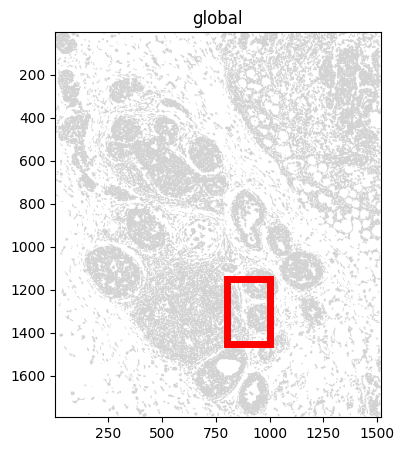

In [5]:
f, ax = plt.subplots(figsize=(5, 5))
sdata_xenium_ws.pl.render_shapes("cell_boundaries").pl.show(ax=ax)
rect = patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

In [6]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)

## Initialize SegTraQ objects

Next, we initialize SegTraQ objects, the core interface for computing SegTraQ metrics.
During initialization, all inputs are are validated via `validate_spatialdata()`.
Don't worry if you do not know which parameters you need up front;
just put in your spatialdata object, and SegTraQ will tell you which arguments are wrong/missing.

The four segmentation methods apply different filters to the points prior to segmentation.
Proseg and BIDCell remove control probes (e.g. NegControlProbe, Intergenic_Region)
before segmentation. In addition, Proseg and BIDCell exclude
transcripts with a quality value (qv, the Xenium per-transcript decoding quality score) < 20.

For a fair comparison of metrics, like the percentage of unassigned transcripts,
across methods, we subset the transcripts to include only gene-specific probes with qv ≥ 20.
This is also compatible with the preprocessing for the cell feature matrix by
[10x Genomics](https://cf.10xgenomics.com/supp/xenium/xenium_documentation.html).

In [7]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

## Load reference scRNA-seq data and transfer labels

To evaluate how SegTraQ metrics differ between cell types,
we first transfer labels from the reference scRNA-seq dataset to the spatial data using
`segtraq.run_label_transfer`.

In [8]:
# Load scRNA-seq data
adata_ref = ad.read_h5ad("../../data/xenium_5K_data/BC_scRNAseq_Janesick.h5ad")

For easier access, we store the `SpatialData` object into a dictionary.

In [9]:
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg}

In [10]:
# Transfer labels
for _method, st in st_dict.items():
    st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_raw_counts_layer="raw", inplace=True)

We can visualize the spatial data and color cell masks by transferred labels using `spatialdata-plot`.

In [11]:
# Define color palette for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

Cells with a transcripts count < 10 and a gene count < 5 are not considered in
label transfer and their returned `transferred_cell_type` returns `np.nan`,
and missing values are subsequently replaced with the label "Unknown".

In [12]:
# Replace NaN with Unknown for plotting
for _method, st in st_dict.items():
    s = st.sdata.tables["table"].obs["transferred_cell_type"]
    if pd.api.types.is_categorical_dtype(s):
        s = s.cat.add_categories(["Unknown"])

    st.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

In [13]:
plt.style.use("dark_background")

In [14]:
def feature_spatial_plot(sdata, shapes_key, feature, col_palette, method):
    axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

    # compute per-cell color
    labels = sdata.tables["table"].obs[feature].unique().astype(str).tolist()
    cols = [col_palette[lab] for lab in labels]

    # Dapi image
    sdata.pl.render_images("image").pl.show(ax=axes[0], title=f"{method}: DAPI image", coordinate_systems="global")

    # Plot - Cell boundaries
    sdata.tables["table"].obs["region"] = shapes_key
    sdata.set_table_annotates_spatialelement("table", region=shapes_key)

    sdata.pl.render_shapes(shapes_key, color=feature, palette=cols, groups=labels).pl.show(
        ax=axes[1], title=f"{method}: Cell masks colored by {feature}", coordinate_systems="global"
    )

*10 Xenium MultiModal Cell Segmentation*

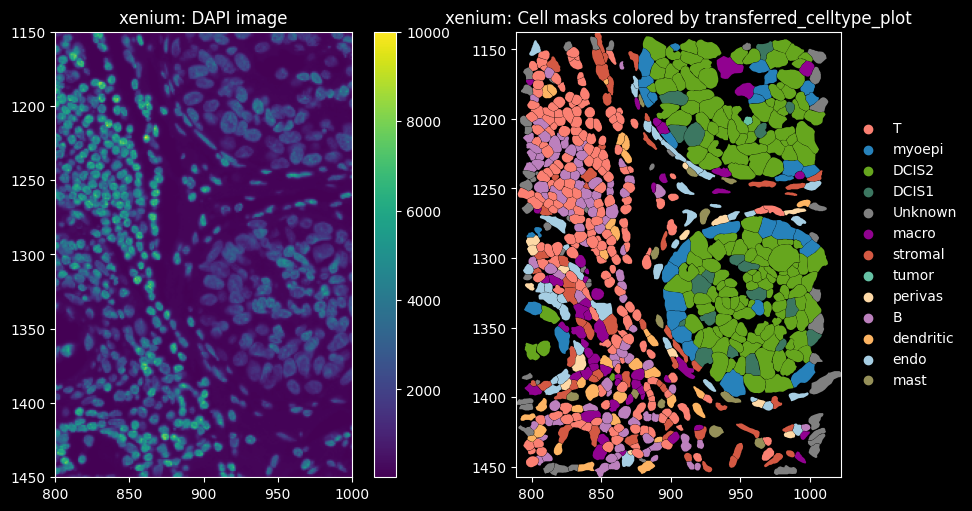

In [15]:
feature_spatial_plot(st_xenium.sdata, "cell_boundaries", "transferred_celltype_plot", col_celltype, "xenium")

*BIDCell Segmentation*

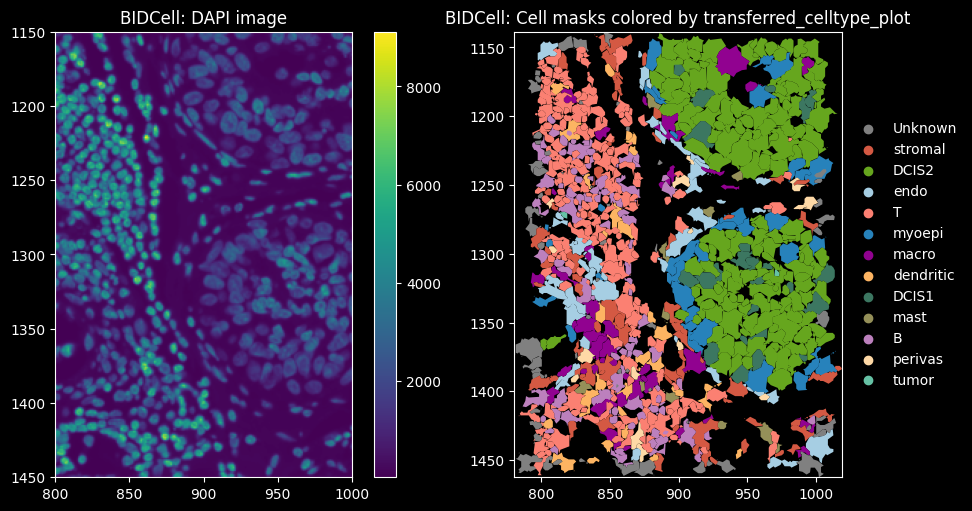

In [16]:
feature_spatial_plot(st_bidcell.sdata, "cell_boundaries", "transferred_celltype_plot", col_celltype, "BIDCell")

*Proseg Segmentation*

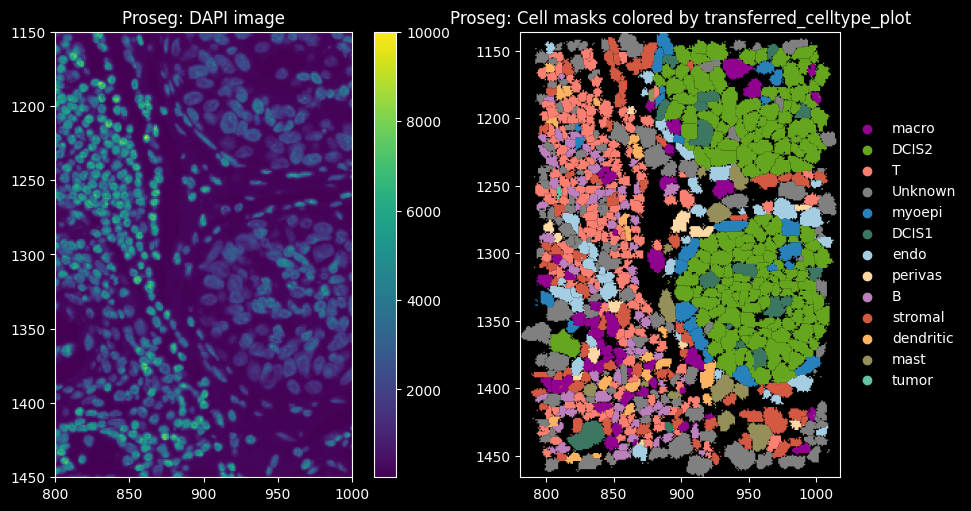

In [17]:
feature_spatial_plot(st_proseg.sdata, "cell_boundaries_z1", "transferred_celltype_plot", col_celltype, "Proseg")

The dominant cell types are DCIS2, T and B cells. Proseg has the highest
proportion of cells assigned to "Unknown", i.e. transcript counts <10 and gene_counts <5.

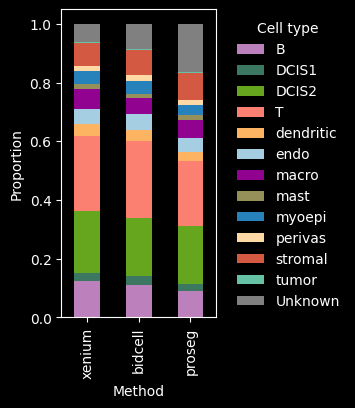

In [18]:
method_dfs = []
for method, st in st_dict.items():
    df = st.sdata["table"].obs["transferred_celltype_plot"].value_counts(normalize=True).reset_index()
    df.columns = ["celltype", "proportion"]
    df["method"] = method
    method_dfs.append(df)

plot_df = pd.concat(method_dfs, ignore_index=True)
plot_wide = plot_df.pivot(index="method", columns="celltype", values="proportion").fillna(0)

method_order = ["xenium", "bidcell", "proseg"]
plot_wide = plot_wide.loc[method_order]

fig, ax = plt.subplots(figsize=(2, 4))

plot_wide.plot(kind="bar", stacked=True, color=[col_celltype.get(c, "grey") for c in plot_wide.columns], ax=ax)

ax.set_ylabel("Proportion")
ax.set_xlabel("Method")

# Legend text in white
legend = ax.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

fig.tight_layout()
plt.show()

## Running SegTraQ QC metrics

Now the data is ready to compute SegTraQ QC metrics.
Below we demonstrate how to run the individual modules.

### Baseline module

The baseline (`bl`) module computes basic quality-control metrics such as the number of cells,
the percentage of unassigned transcripts, and the number of transcripts and genes per cell.
When `inplace=True`, global metrics are stored in the `uns` slot, and per-cell metrics
are stored in the `obs` slot of the table within the `SpatialData` object.

In [19]:
for method, st in st_dict.items():
    st.bl.num_cells(inplace=True)
    st.bl.perc_unassigned_transcripts(inplace=True)
    st.bl.transcripts_per_cell()
    st.bl.genes_per_cell()
    st.bl.mean_transcripts_per_gene_per_cell()

    num_cells = st.sdata.tables["table"].uns["num_cells"]
    p_unassigned = st.sdata.tables["table"].uns["perc_unassigned_transcripts"]
    mean_tx = st.sdata.tables["table"].obs["transcript_count"].mean()
    mean_gn = st.sdata.tables["table"].obs["gene_count"].mean()
    mean_tgc = st.sdata.tables["table"].obs["mean_transcripts_per_gene"].mean()

    print(f"\n{method}")
    print(f"#cells: {num_cells}; %unassigned: {p_unassigned}")
    print(f"mean #transcripts: {mean_tx}; mean #genes: {np.mean(mean_gn)}")
    print(f"mean #transcripts per gene per cell: {mean_tgc}")


xenium
#cells: 751; %unassigned: 7.701023026425406
mean #transcripts: 110.6444740346205; mean #genes: 91.77762982689747
mean #transcripts per gene per cell: 1.129141779055404



bidcell
#cells: 760; %unassigned: 8.024574774194265
mean #transcripts: 108.93157894736842; mean #genes: 90.1078947368421
mean #transcripts per gene per cell: 1.1083750146793525



proseg
#cells: 745; %unassigned: 0.8153109622668755
mean #transcripts: 119.7489932885906; mean #genes: 94.57718120805369
mean #transcripts per gene per cell: 1.1291160754325535


The number of detected cells is comparable across Xenium, BIDCell, and Proseg.
Proseg leaves the smallest fraction of transcripts unassigned (0.81%).
The number of transcripts and genes per cell can be visualized per cell type, as shown below.

In [20]:
# method for visualization
def boxplot_per_celltype(st_dict, feature, q=1):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()]
        tmp = obs[["transferred_cell_type", feature]].copy()
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)
    df = df[(df[feature] <= df[feature].quantile(q))]

    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(
        data=df,
        x="transferred_cell_type",
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette="Set2",
        ax=ax,
    )

    fig.tight_layout()
    plt.show()

Proseg yields the highest mean number of transcripts per cell,
driven by increased transcript detection in DCIS2 and T, B and stromal cells,
which constitute the dominant cell populations in the dataset.
In contrast, Proseg detects fewer transcripts in some of the less abundant cell types,
such as DCIS1 and myoepithelial cells.

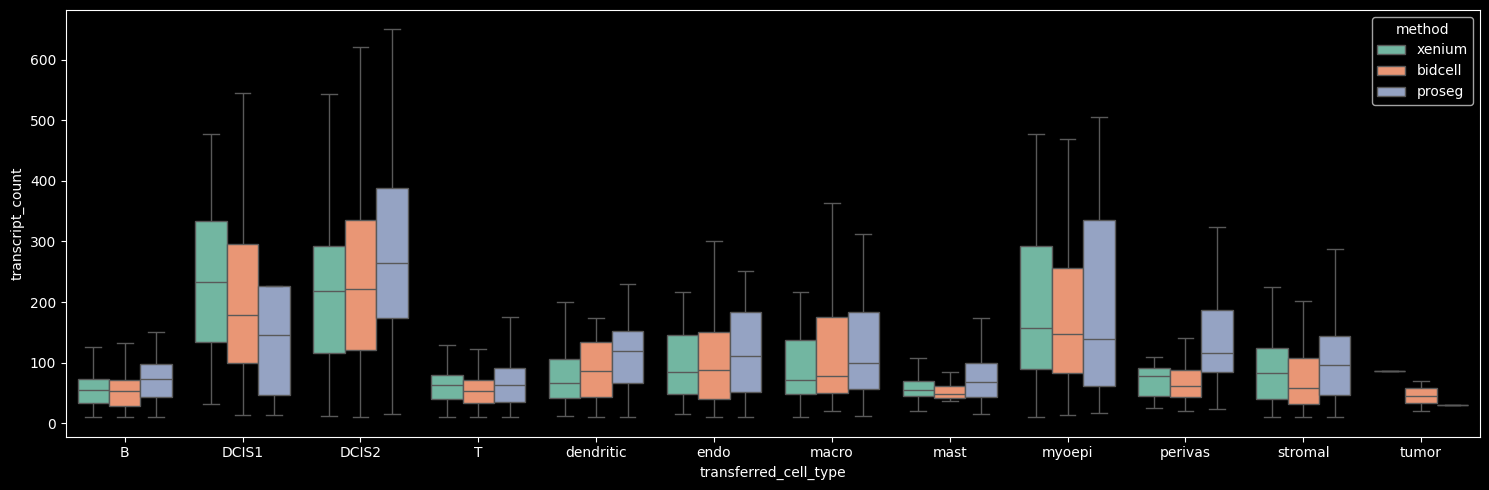

In [21]:
boxplot_per_celltype(st_dict, "transcript_count")

The number of genes detected per cell correlates strongly with the number of transcripts per cell.

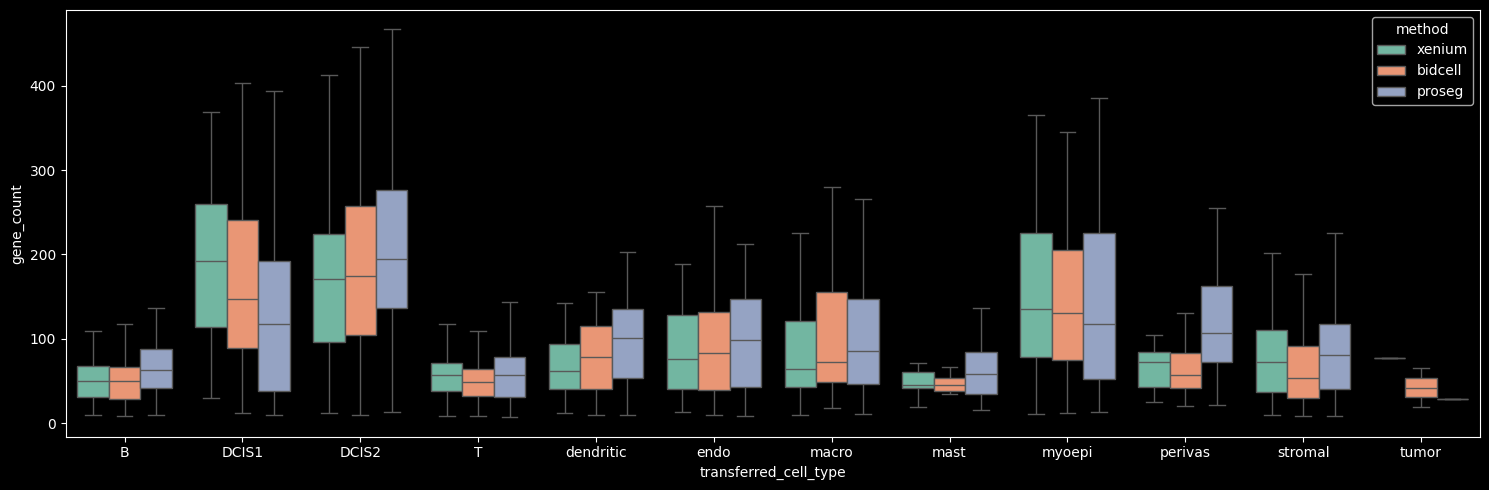

In [22]:
boxplot_per_celltype(st_dict, "gene_count")

On average, the number of transcripts per gene per cell is approximately 1,
indicating that across methods we detect roughly one to two transcripts per gene per cell.
Among the methods, Proseg shows the highest mean number of transcripts per gene
per cell when the *Unknown* cluster (cells with transcript counts < 10 and gene counts < 5) is excluded.

Interestingly, Proseg detects more transcripts per gene per cell across all cell types,
even in cases where the total transcript and gene counts per cell are lower,
e.g., DCIS1 and myoepithelial cells.
This pattern suggests that transcripts are concentrated among fewer genes per cell,
potentially reflecting more homogeneous within-cell expression profiles (i.e. reduced gene-level variability).

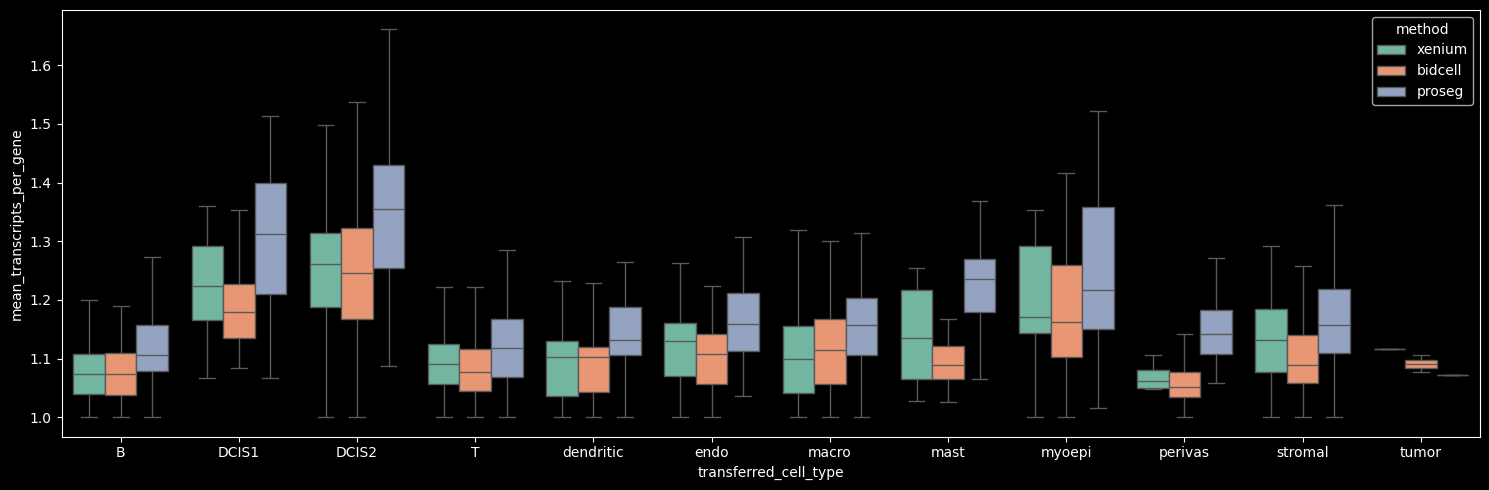

In [23]:
boxplot_per_celltype(st_dict, "mean_transcripts_per_gene")

The baseline module also facilitates the computation of **morphological features**.

In [24]:
for _method, st in st_dict.items():
    st.bl.morphological_features(n_jobs=8)

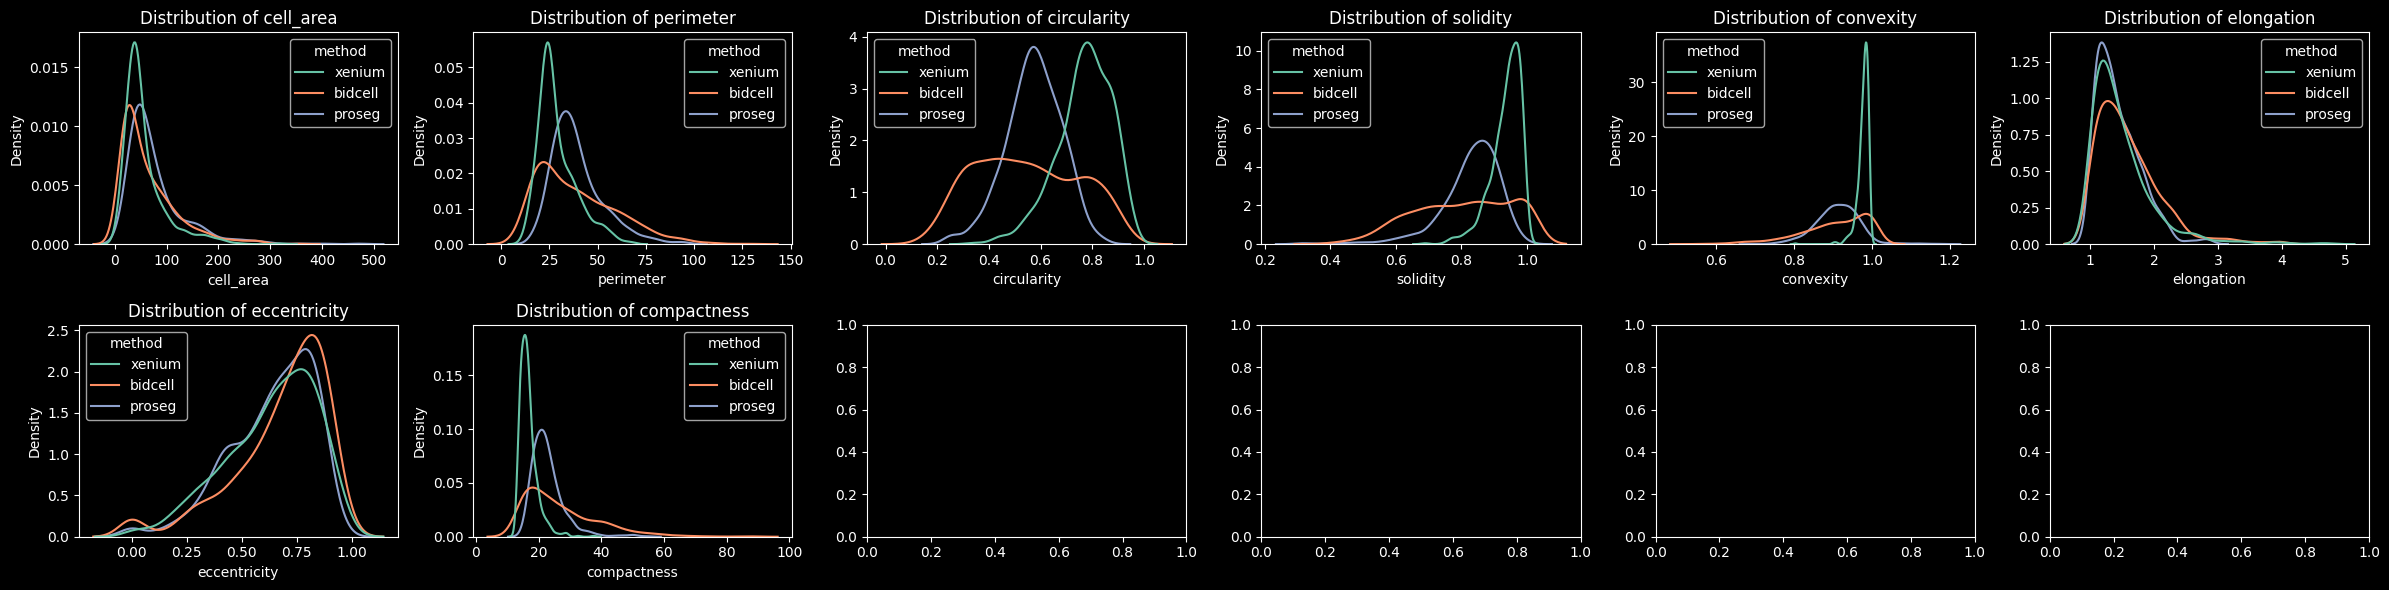

In [25]:
features = [
    "cell_area",
    "perimeter",
    "circularity",
    "solidity",
    "convexity",
    "elongation",
    "eccentricity",
    "compactness",
]

# Collect features into one dataframe
all_feats = []
for method, st in st_dict.items():
    obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()]
    feat = obs[features]
    tmp = feat.copy()
    tmp["method"] = method
    all_feats.append(tmp)

df = pd.concat(all_feats, ignore_index=True)
df["method"] = df["method"].astype(str)

feature_cols = [c for c in df.columns if c != "method"]

fig, ax = plt.subplots(2, 6, figsize=(6 * 4, 2 * 3))
ax = ax.flatten()

for i, feat_name in enumerate(feature_cols):
    sns.kdeplot(data=df, x=feat_name, hue="method", palette="Set2", common_norm=False, fill=False, ax=ax[i])
    ax[i].set_title(f"Distribution of {feat_name}")
    ax[i].set_xlabel(feat_name)
    ax[i].set_ylabel("Density")
fig.tight_layout()
plt.show()

Xenium detects rounder cells, characterized by higher circularity and solidity,
while BIDCell recovers a wider distribution of cell shapes,
including both low and high circularity and solidity.
BIDCell incorporates a loss term enforcing cell type–specific elongation,
which may explain the detection of less circular cell shapes.
Notably, the same cell types specified as elongated during training
(perivascular, myoepithelial, stromal, and endothelial cells) also exhibit the highest
median elongation in the results, highlighting the strong influence of the prior on
the inferred cell shapes.

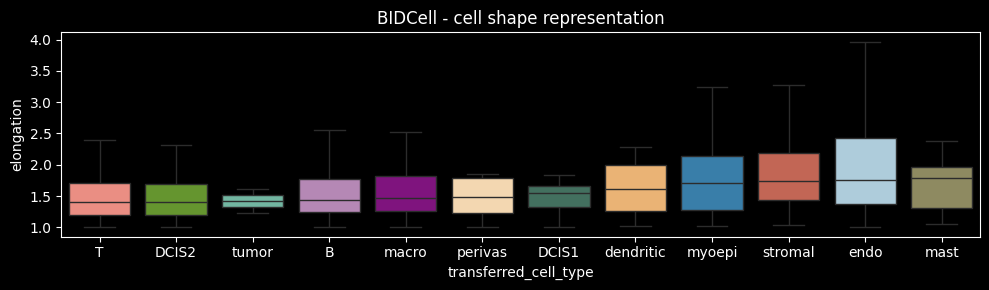

In [26]:
obs = st_bidcell.sdata["table"].obs[st_bidcell.sdata["table"].obs["transferred_cell_type"].notna()]
df = obs[["transferred_cell_type", "elongation"]]
medians = df.groupby("transferred_cell_type").median()
order = medians.sort_values(by="elongation").index

fig, ax = plt.subplots(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="transferred_cell_type",
    y="elongation",
    order=order,
    showcaps=True,
    showfliers=False,
    palette=col_celltype,
    ax=ax,
)

ax.set_title("BIDCell - cell shape representation")
fig.tight_layout()
plt.show()

Proseg, in contrast, does not rely solely on membrane stainings.
Instead, it incorporates transcript positions,
which may extend beyond the membrane boundary due to diffusion.
This may explain why perivascular or myoepithelial cells do not appear
among the most elongated cell types. Importantly, a segmentation mask that accurately
delineates cell geometry may still misassign transcripts
(e.g. due to diffusion or spatial overlap), while a mask that poorly represents
cell shape may nonetheless correctly assign transcripts.
Therefore, it is essential to evaluate not only the geometric accuracy of
cell shapes but also the accuracy of transcript assignment to cells.
We will compute metrics to evaluate transcript assignment accuracy below.

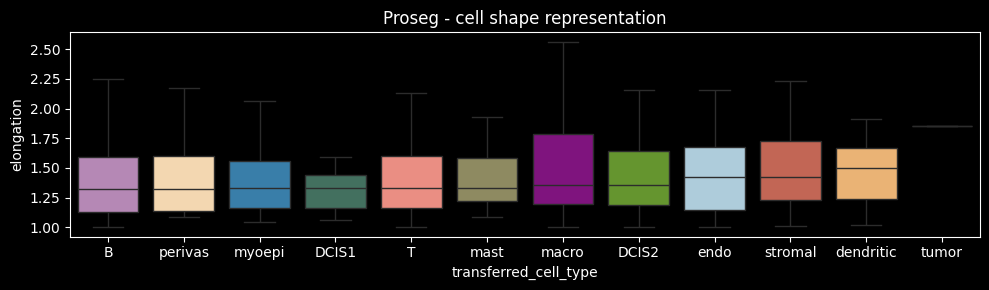

In [27]:
obs = st_proseg.sdata["table"].obs[st_proseg.sdata["table"].obs["transferred_cell_type"].notna()]
df = obs[["transferred_cell_type", "elongation"]]
medians = df.groupby("transferred_cell_type").median()
order = medians.sort_values(by="elongation").index

fig, ax = plt.subplots(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="transferred_cell_type",
    y="elongation",
    order=order,
    showcaps=True,
    showfliers=False,
    palette=col_celltype,
    ax=ax,
)

ax.set_title("Proseg - cell shape representation")
fig.tight_layout()
plt.show()

### Clustering stability module
The clustering stability (`cs`) module provides metrics for assessing the stability
of clustering results across different resolutions and random subsets of genes.

Let`s first perform Leiden clustering and visualize the clusters in the UMAP space.

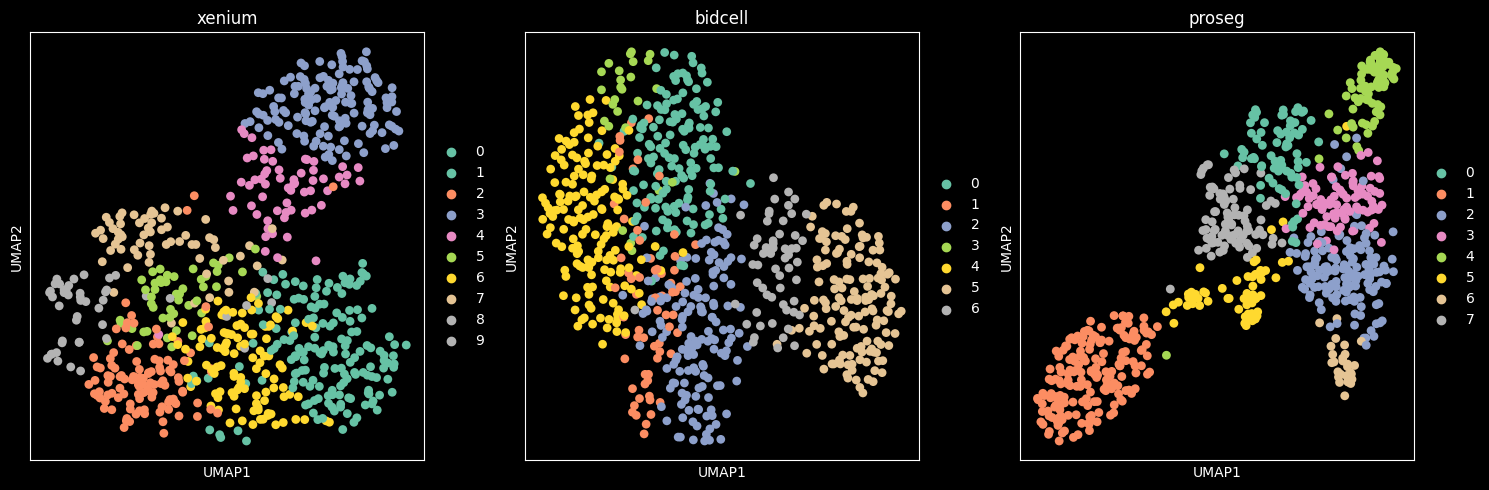

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs = axs.flatten()

for i, (method, st) in enumerate(st_dict.items()):
    adata = st.sdata.tables["table"].copy()
    adata.layers["counts"] = adata.X
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

    sc.pl.umap(
        adata,
        color="leiden",
        palette="Set2",
        ax=axs[i],
        show=False,
        title=method,
    )

plt.tight_layout()
plt.show()

Next, we compute clustering stability metrics and plot these.

In [29]:
ccds = {}
silhouette_scores = {}
purities = {}
aris = {}

for method, st in st_dict.items():
    ccds[method] = st.cs.cluster_connectedness()
    silhouette_scores[method] = st.cs.silhouette_score()
    purities[method] = st.cs.purity()
    aris[method] = st.cs.adjusted_rand_index()

In [30]:
results_df = pd.DataFrame(
    {
        "Method": list(ccds.keys()),
        "Connectedness": list(ccds.values()),
        "Silhouette Score": list(silhouette_scores.values()),
        "Purity": list(purities.values()),
        "ARI": list(aris.values()),
    }
)

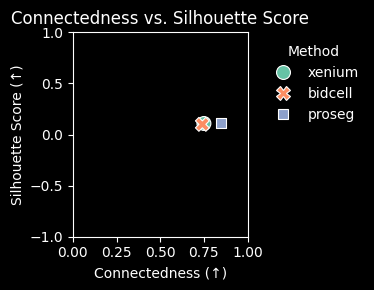

In [31]:
fig, ax = plt.subplots(figsize=(4, 3))

sns.scatterplot(
    data=results_df,
    x="Connectedness",
    y="Silhouette Score",
    hue="Method",
    style="Method",
    s=100,
    palette="Set2",
    ax=ax,
)

ax.set_xlabel("Connectedness (↑)")
ax.set_ylabel("Silhouette Score (↑)")
ax.set_title("Connectedness vs. Silhouette Score")
ax.set_xlim(0, 1)
ax.set_ylim(-1, 1)
legend = ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
plt.show()

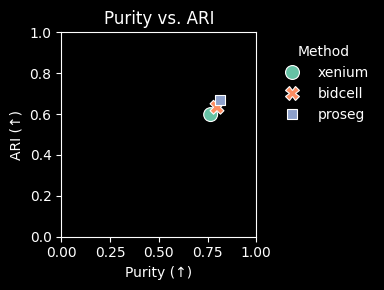

In [32]:
fig, ax = plt.subplots(figsize=(4, 3))

sns.scatterplot(
    data=results_df,
    x="Purity",
    y="ARI",
    hue="Method",
    style="Method",
    s=100,
    palette="Set2",
    ax=ax,
)

ax.set_xlabel("Purity (↑)")
ax.set_ylabel("ARI (↑)")
ax.set_title("Purity vs. ARI")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

legend = ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
plt.show()

Proseg achieves the highest adjusted Rand index (ARI) and clustering purity,
as well as the lowest mean cosine distance. Together,
these results suggest that Proseg retrieves the most internally consistent expression
profiles and could indicate less contaminated single cell signatures.

The silhouette score can also be computed on the transferred labels.
We will first visualize transferred labels in the UMAP space.

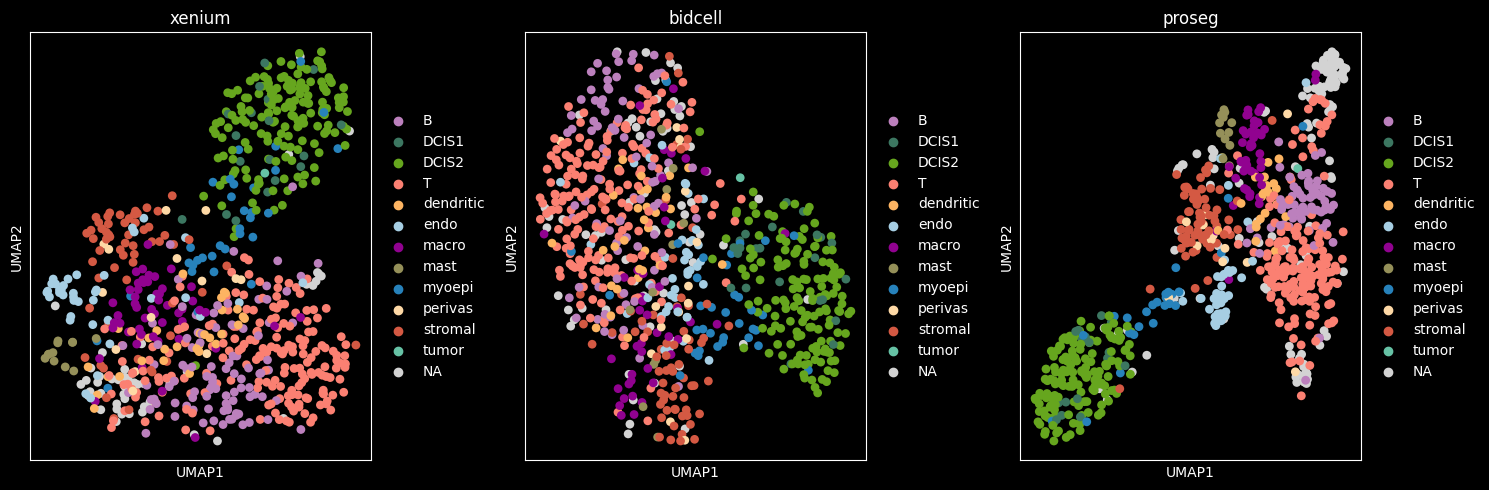

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs = axs.flatten()

for i, (method, st) in enumerate(st_dict.items()):
    adata = st.sdata.tables["table"].copy()

    # normalizing and log-transforming the counts
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    # computing a PCA and neighbors
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

    sc.pl.umap(
        adata,
        color="transferred_cell_type",
        palette=col_celltype,
        ax=axs[i],
        show=False,
        title=method,
    )

plt.tight_layout()
plt.show()

Proseg achieves the highest silhouette score for the transferred labels,
indicating higher intra-cluster coherence and improved inter-cluster separation;
this is also visually consistent with the UMAP embedding.

In [34]:
silhouette_scores_labels = {}

for method, st in st_dict.items():
    silhouette_scores_labels[method] = st.cs.silhouette_score(cell_type_key="transferred_cell_type")

silhouette_scores_labels

{'xenium': -0.027014529332518578,
 'bidcell': -0.02936074323952198,
 'proseg': 0.03824570029973984}

## Region similarity module

While individual genes may exhibit subcellular localization patterns,
the overall distribution of transcripts, when averaged across genes,
is expected to be relatively smooth and approximately uniform within a cell.
Based on this assumption, the region similarity module evaluates the
similarity of gene expression profiles across different subcellular compartments.
Deviations from this expected intra-cellular consistency can serve as indicators of
transcript contamination originating from neighboring cells.

*Intersection over Union (IoU)*

Proseg shows the lowest intersection over union (IoU) between the cell and nucleus.
It relies on transcript assignment rather than explicit morphology-based segmentation,
allowing transcripts that are repositioned outside the cell membrane
(e.g. due to transcript diffusion) to be reassigned to the cell of origin.
This often results in larger inferred cell areas (or perimeters, as shown above)
relative to the nucleus or less aligned cell and nucleus shapes, leading to
lower cell–nucleus IoU values.

In [35]:
plt.style.use("default")


def plot_IoU(sdata, shapes_key, method, ax):
    # note that copy.deepcopy() can have unwanted effects on the attrs, hence sd.deepcopy() is preferred
    sdata_plot = sd.deepcopy(sdata)
    sdata_plot["table"] = sdata_plot["table"][(sdata_plot["table"].obs["iou"].notna())]

    sdata_plot.tables["table"].obs["region"] = shapes_key
    sdata_plot.set_table_annotates_spatialelement("table", region=shapes_key)

    sdata_plot.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element=shapes_key,
        color="iou",
        cmap="viridis",
        fill_alpha=0.5,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.show(ax=ax, title=f"{method}: Overlay of nuclei and cell masks colored by IoU", colorbar=True)

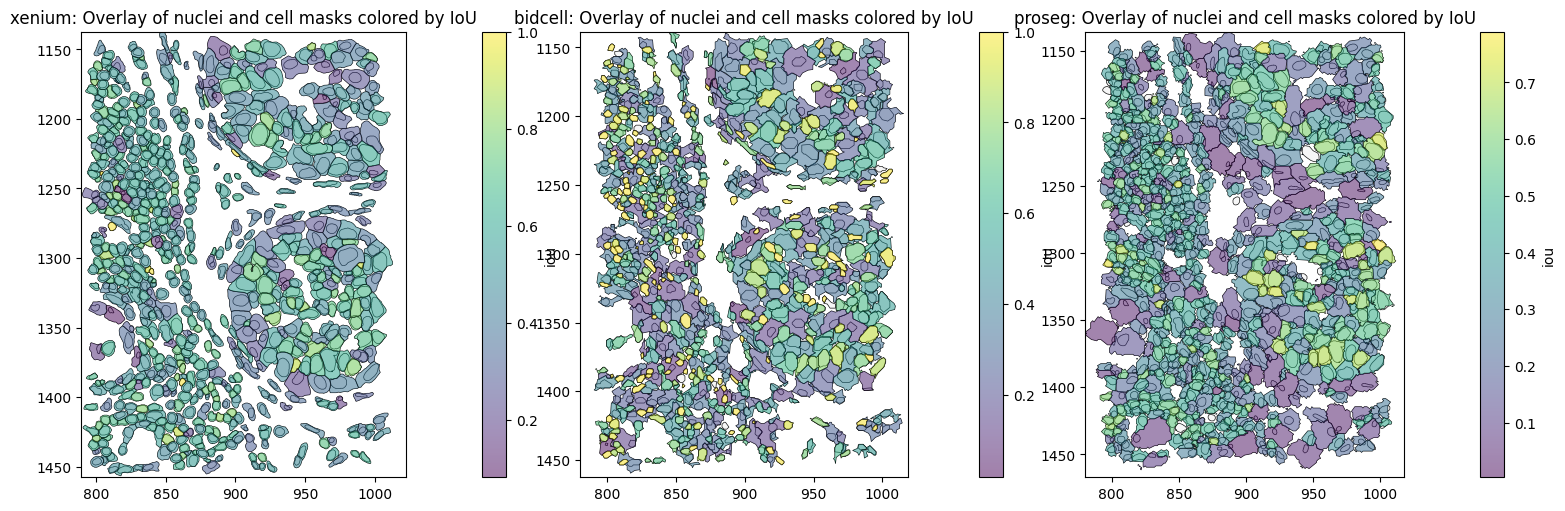

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for i, (method, st) in enumerate(st_dict.items()):
    st.rs.match_nuclei_to_cells(n_jobs=-1)
    plot_IoU(st.sdata, "cell_boundaries", method, axes[i])

*Similarity between expression in cell and nucleus*

Once, the "best-matching" nucleus is determined for each cell based on IoU,
we can compute the similarity between cell and nuclear expression.

In [37]:
for _method, st in st_dict.items():
    st.rs.similarity_nucleus_cell(n_jobs=-1)

When the intersection-over-union (IoU) between the cell and nucleus masks is high,
a large fraction of transcripts assigned to the cell also overlap with the nucleus.
Consequently, the returned similarity metric is strongly correlated with IoU.

In [38]:
def plot_correlation(sdata, method, ax):
    obs = sdata.tables["table"].obs
    df = obs[["iou", "similarity_nucleus_cell"]].dropna()

    _slope, _intercept, r_value, _p_value, _std_err = linregress(df["iou"], df["similarity_nucleus_cell"])
    r_squared = r_value**2

    ax = sns.regplot(
        data=df,
        x="iou",
        y="similarity_nucleus_cell",
        ax=ax,
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"},
        ci=95,
    )

    ax.text(
        0.05,
        0.95,
        f"$R^2 = {r_squared:.3f}$",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_xlabel("IoU")
    ax.set_ylabel("Cosine similarity between cell and nucleus intersection")
    ax.set_title(f"{method}: Cell-nuc similarity vs. IoU with Regression Line")
    ax.grid(True)

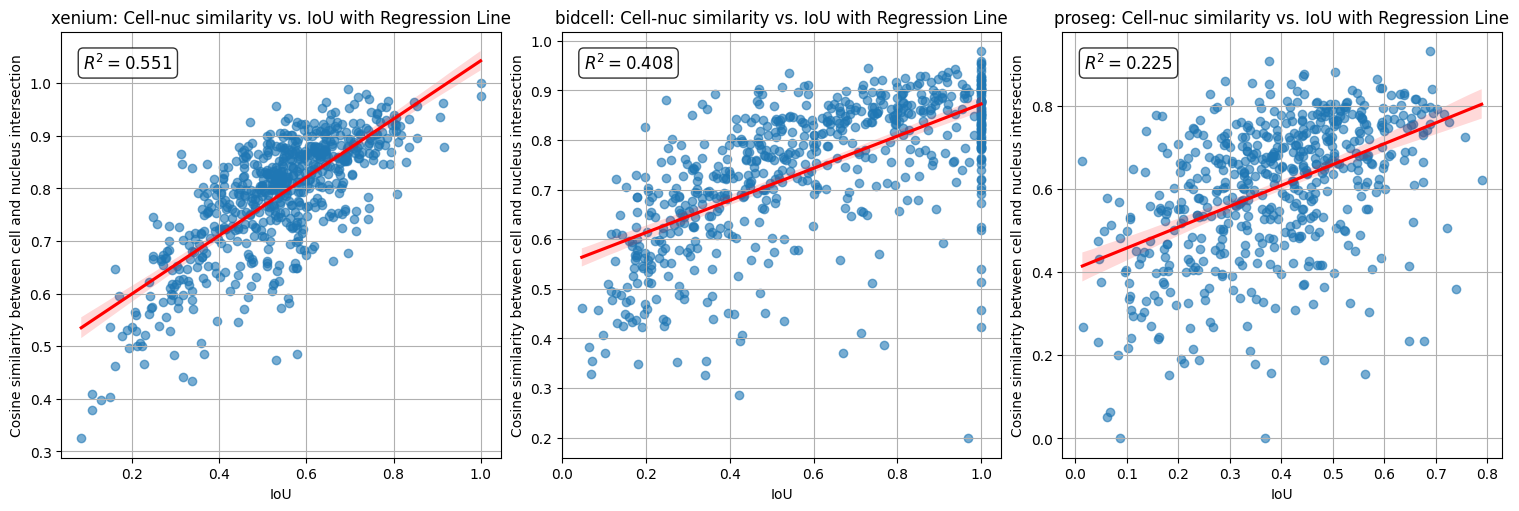

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for i, (method, st) in enumerate(st_dict.items()):
    plot_correlation(st.sdata, method, axes[i])

plt.show()

A more informative metric is therefore the similarity in gene expression
between the region where the cell and nucleus overlap and the remaining cell area,
corresponding to the cytoplasm.

In [40]:
for _method, st in st_dict.items():
    st.rs.similarity_nucleus_cytoplasm(n_jobs=-1)

This metric shows higher values for Xenium and Proseg, which may indicate reduced
transcript contamination in the cytoplasmic compartment.

In [41]:
def density_plot_feature(sdata_dict, features):
    all_feats = []
    for method, st in sdata_dict.items():
        feat = st.sdata["table"].obs[features]
        tmp = feat.copy()
        tmp["method"] = method
        all_feats.append(tmp)

    df = pd.concat(all_feats, ignore_index=True)
    df["method"] = df["method"].astype(str)

    feature_cols = [c for c in df.columns if c != "method"]

    plt.style.use("dark_background")

    n = len(feature_cols)
    n_cols = min(3, n)
    n_rows = np.ceil(n / n_cols).astype(int)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 2 * n_rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, feat in zip(axes, feature_cols, strict=False):
        sns.kdeplot(data=df, x=feat, hue="method", common_norm=False, palette="Set2", fill=False, ax=ax)

    fig.tight_layout()
    plt.show()

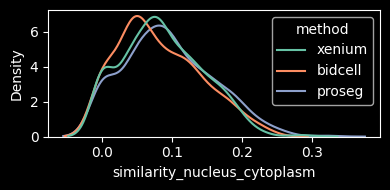

In [42]:
features = ["similarity_nucleus_cytoplasm"]
density_plot_feature(st_dict, features)

*Similarity of gene expression between
(1) cell center and cell border and
(2) cell border and cell neighborhood*

To better disentangle biology from technical contamination,
we introduced a metric that evaluates expression similarity
between the cell center and the cell border.
The underlying assumption is that although genes may differ between nucleus and cytoplasm,
their expression should not systematically differ between the interior cytoplasm and the cell periphery.
To quantify potential contamination, we compare the expression similarity of
(i) the cell border and its eroded cell center and
(ii) the cell border and its local neighborhood.

In [43]:
for _method, st in st_dict.items():
    st.rs.similarity_border_neighborhood()
    st.rs.similarity_center_border()

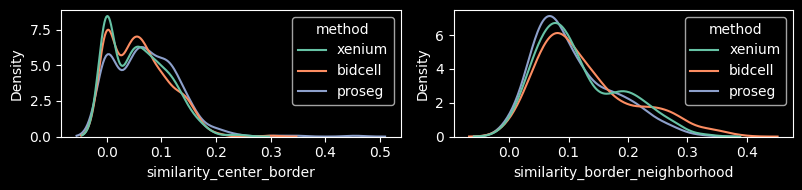

In [44]:
features = ["similarity_center_border", "similarity_border_neighborhood"]
density_plot_feature(st_dict, features)

*Admixture (contamination) of the cell border*

A low `similarity_center_border` or high `similarity_border_neighborhood` does
not necessarily represent contamination. To evaluate the contamination of the
cell border robustly, we compute the the `border_admixture_score`,
which explicitly models the border as a mixture of center and neighborhood expression,
and estimates how much better this mixture explains the border compared to the center alone.

In [45]:
for _method, st in st_dict.items():
    st.rs.border_admixture_score()

A high `border_admixture_score` means the border is better explained by the
mixture than by the center alone. The density plot below shows that Proseg
and BIDCell shows the least contamination. It is important to note that Proseg
is a transcript-assignment method, meaning that transcripts located near or even within
a cell boundary are not necessarily assigned to that cell. When computing the border admixture score,
transcripts in the border region that are assigned to other cells must therefore be excluded.
This can increase sparsity and noise in the data and may lead to less stable estimates.

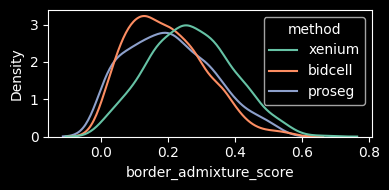

In [46]:
features = ["border_admixture_score"]
density_plot_feature(st_dict, features)

While it is important to consider metrics that do not depend on the availability of
high-quality reference scRNA-seq data—and therefore do not rely on the performance of
label transfer—a limitation of the region similarity module is that it cannot
distinguish between homogeneous and heterogeneous cellular neighborhoods.
In homogeneous neighborhoods, a high `border_admixture_score` does not necessarily
indicate contamination. Nevertheless, when comparing methods globally or on a
cell-type level, this is a useful unsupervised contamination metric that does
not rely on reference scRNA-seq data.

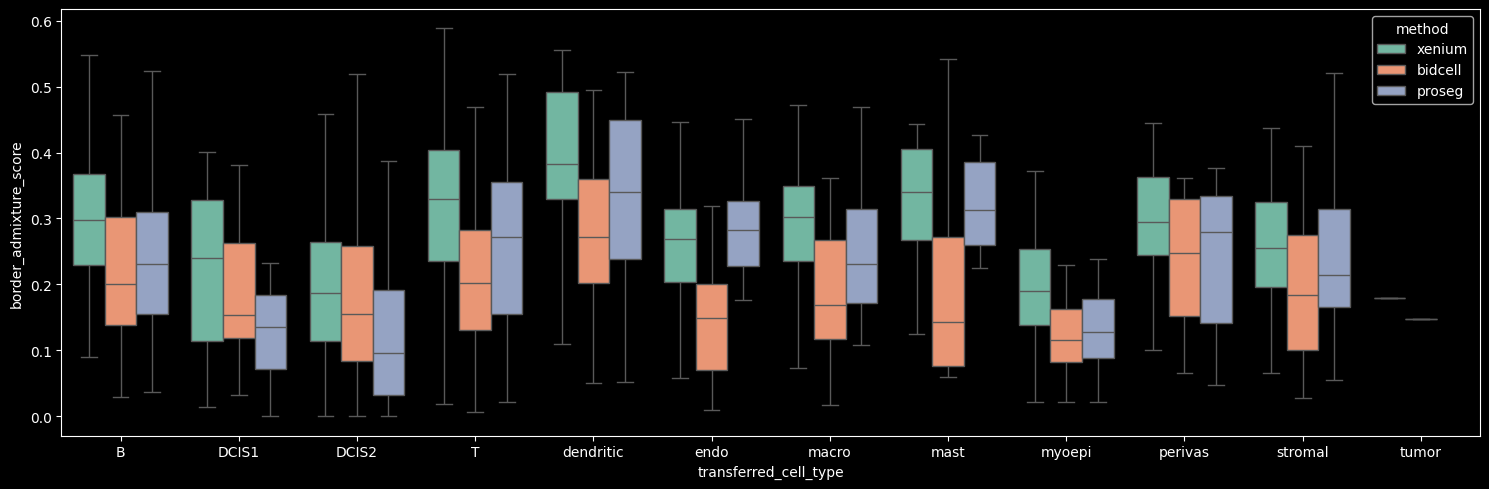

In [47]:
boxplot_per_celltype(st_dict, "border_admixture_score")

### Supervised module

The `sp` (supervised) module provides metrics to evaluate how well cell profiles
in a spatial transcriptomics dataset agree with a reference single-cell RNA-seq
(scRNA-seq) dataset with cell type annotations.

Unlike scRNA-seq, contamination in spatial transcriptomics measurements mostly originates
from the local tissue context.

By comparing spatial expression profiles to a high-quality scRNA-seq reference,
the supervised module aims to quantify this mismatch. Specifically, we compute metrics that measure:
- how well each spatial cell matches its expected cell type,
- how much its expression resembles other (neighboring) cell types, and
- if it is possible to predict that a cell of one cell type is adjacent to a different cell type.

To obtain cell-type specific marker genes, we define positive and negative markers in the
annotated scRNA-seq via `markers_from_reference`.

*Computing cell-type specific markers*

In [48]:
markers = {}
for method, st in st_dict.items():
    markers[method] = st.markers_from_reference(
        adata_ref,
        ref_cell_type="celltype_major",
        ref_raw_counts_layer="raw",
        n_jobs=16,
    )

A list of positive and negative markers computed for each cell type is shown below.
We will use xenium for demonstration.

In [49]:
for cell_type, sign in markers["xenium"].items():
    pos = sign["positive"]
    neg = sign["negative"]

    print(f"{cell_type}  |  positive: {', '.join(pos)}")
    print(f"{cell_type}  |  negative: {', '.join(neg)}\n")

B  |  positive: PAX5, MS4A1, BANK1, FCRL1, BLK, FCRL2, AIM2, TNFRSF13B, CD19, POU2AF1, SCIMP, FCRL5, P2RX5, CD79A, PARP15, CD79B, TNFRSF13C, POU2F2, FCRLA, STAP1, CD22, COL4A3, SP140, NIBAN3, CR1, ADAM28, PLCG2, FCMR, CD40, TLR6, ST6GAL1, DERL3, KCNN4, CD27, CD52, ITGB7, BLNK, CNR2, COL4A4, SPIB, IRF4, TNFRSF17, ZBP1, PTK2B, FCGR2B, CDK14, PTPN6, TNFAIP8, SP110, ATM, FCRL3, COCH, CCDC141, NCF1, CD38, CCR6, ITGAL, RELT, PIM2, SMCHD1, ANKRD13A, NCOA3, PDK1, LRRK2, KCNA3, NLRP1, TLR1, SLAMF1, SLAMF6, GPR174, JAK3, GRK5, NLRC5, SMAP2, BCL2, SYVN1, TENT5C, ORAI2, CASP10, CYSLTR1, CD83, LPXN, TRAF5, REL, BTN3A1, SYNRG, ATP2B1, SEMA4B
B  |  negative: ABCA10, ABCA8, ABCC8, ABCC9, ABI3BP, AC007906.2, ACVRL1, ADAM12, ADAM33, ADAMDEC1, ADAMTS1, ADAMTS12, ADAMTS14, ADAMTS2, ADAMTS4, ADAMTS5, ADCYAP1, ADGRE2, ADGRL4, ADORA2B, ADORA3, ADRA1B, ADRA2A, ADTRP, AFAP1L2, AGR3, AIF1, ALDH7A1, ALPK3, ALPL, ANGPT1, ANGPTL2, ANGPTL4, ANXA3, ANXA8, APLNR, AQP1, ASPN, ATL1, AVPR1A, AXIN2, BAALC, BARX2, BCL6B, 

Below, we show the number of negative markers that overlap with the positive markers of each cell type.
To reliably estimate contamination, each cell type should share
**at least ~5 negative markers** with the positive marker set of every other cell type.
If these overlaps are too small, contamination estimates become unstable.

In such cases, the marker definition can be relaxed by adjusting the thresholds used in
`markers_from_reference` above.

In [50]:
ctypes = list(markers["xenium"].keys())
overlap_df = pd.DataFrame(0, index=ctypes, columns=ctypes, dtype=int)

for c in ctypes:
    neg_c = set(markers["xenium"][c].get("negative", []))
    for d in ctypes:
        pos_d = set(markers["xenium"][d].get("positive", []))
        overlap_df.loc[d, c] = len(neg_c & pos_d)

overlap_df

,B,DCIS1,DCIS2,T,dendritic,endo,macro,mast,myoepi,perivas,stromal,tumor
B,0,50,48,41,26,44,29,47,41,49,48,57
DCIS1,49,0,20,75,50,37,48,50,12,41,37,23
DCIS2,39,16,0,78,41,27,40,56,5,29,25,12
T,26,48,52,0,27,37,24,43,33,28,47,66
dendritic,50,66,63,73,0,49,42,70,48,53,56,70
endo,108,90,92,110,101,0,94,86,63,45,66,95
macro,71,76,74,102,49,60,0,74,48,79,54,88
mast,28,27,29,37,24,24,20,0,20,28,27,30
myoepi,97,33,58,98,85,55,85,70,0,59,61,75
perivas,87,49,60,109,70,6,80,92,34,0,24,71


*Marker purity*

To quantify how well each segmented cell in the spatial transcriptomics data
matches its annotated cell type, we defined a marker-based purity (`marker_balanced_accuracy`)
score that jointly evaluates the expression of positive (`positive_marker_recall`) and
the absence of neighborhood-associated negative markers (`negative_marker_avoidance`).
The method accounts for the spatial context of each cell and is motivated by the assumption
that differences between scRNA-seq and spatial transcriptomics-derived cell type profiles
arise mainly from local contamination by neighboring cells.

In [51]:
for method, st in st_dict.items():
    purity = st.sp.marker_purity(
        cell_type_key="transferred_cell_type",
        markers=markers[method],
        inplace=True,
    )

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


Proseg exhibits the highest `marker_balanced_accuracy` across most cell types, with the exception of DCIS1.
To better interpret the overall purity scores, it is informative to examine the `positive_marker_recall`
and `negative_marker_avoidance` scores separately, as they capture distinct aspects of marker specificity.

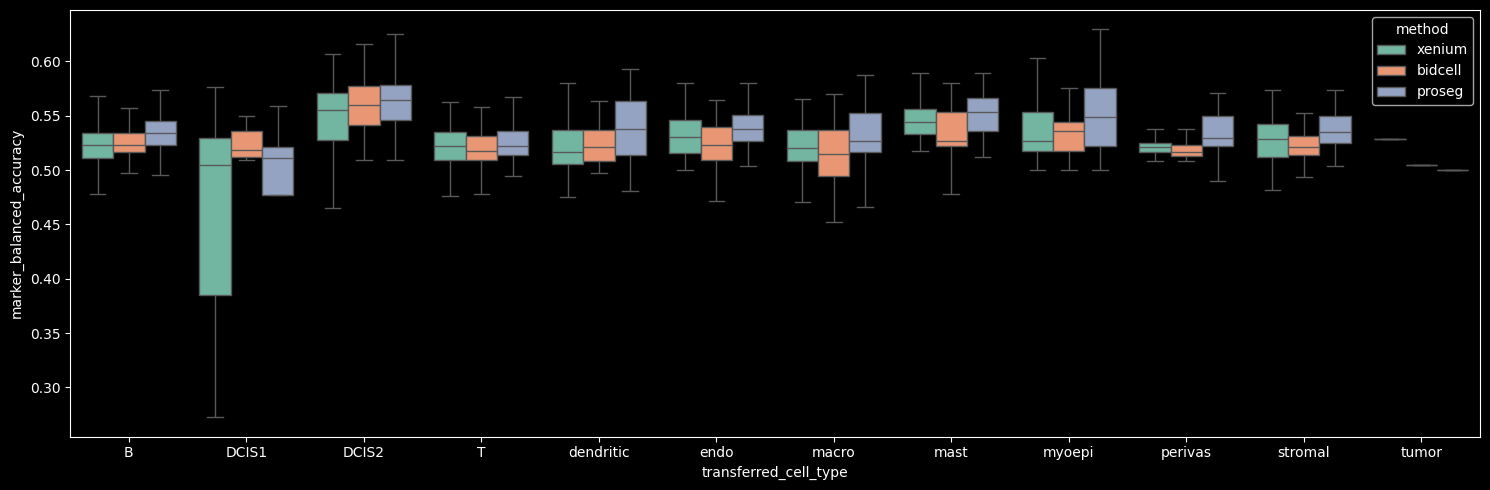

In [52]:
boxplot_per_celltype(st_dict, "marker_balanced_accuracy")

The `negative_marker_avoidance` score quantifies the extent to which a focal cell expresses positive
markers of neighboring cell types, and thus reflects contamination. Overall, contamination levels are low;
however, increased contamination is observed for DCIS1.

In [53]:
def box_strip_plot_per_celltype(
    st_dict,
    feature,
    celltype_col="transferred_cell_type",
    q=1.0,
    figsize=(15, 5),
    palette="Set2",
):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata.tables["table"].obs
        tmp = obs[[celltype_col, feature]].copy()
        tmp = tmp[tmp[celltype_col].notna()]
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True).dropna(subset=[celltype_col, feature])

    if q < 1:
        df = df[df[feature] <= df[feature].quantile(q)]

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df,
        x=celltype_col,
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette=palette,
        ax=ax,
    )

    sns.stripplot(
        data=df,
        x=celltype_col,
        y=feature,
        hue="method",
        dodge=True,
        jitter=0.2,
        alpha=0.6,
        linewidth=0,
        palette=palette,
        ax=ax,
    )

    # avoid duplicate legends
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title="method")

    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Cell type")
    ax.set_ylabel(feature)
    ax.legend(title="method", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

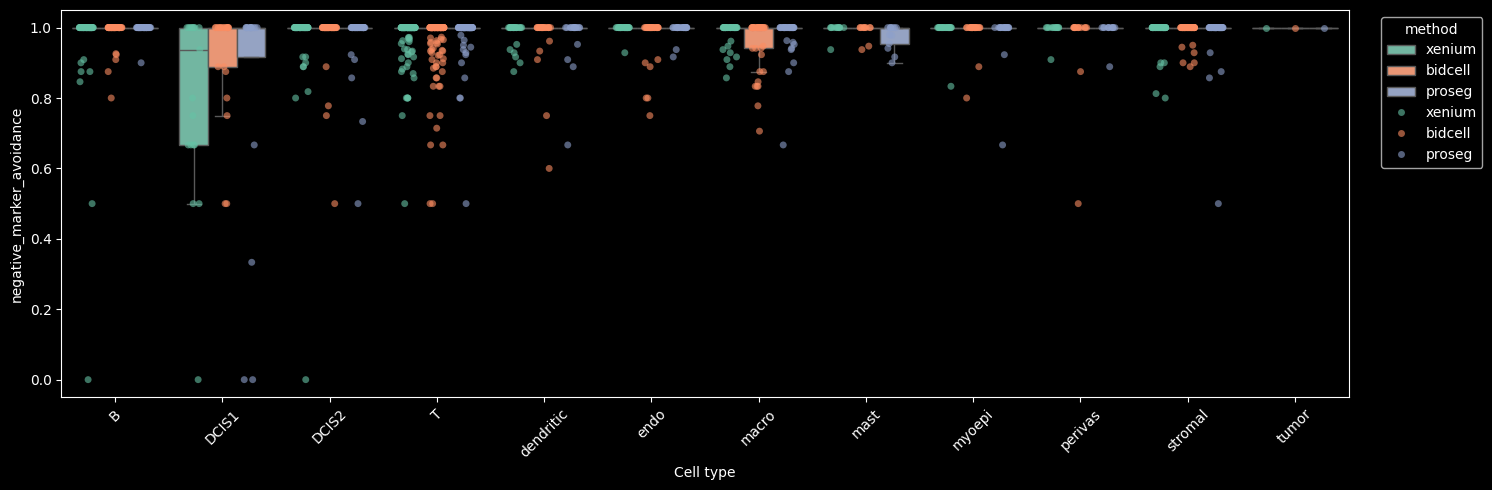

In [54]:
box_strip_plot_per_celltype(st_dict, "negative_marker_avoidance")

In contrast, the `positive_marker_recall` score measures how consistently a cell
expresses markers expected for its assigned cell type.

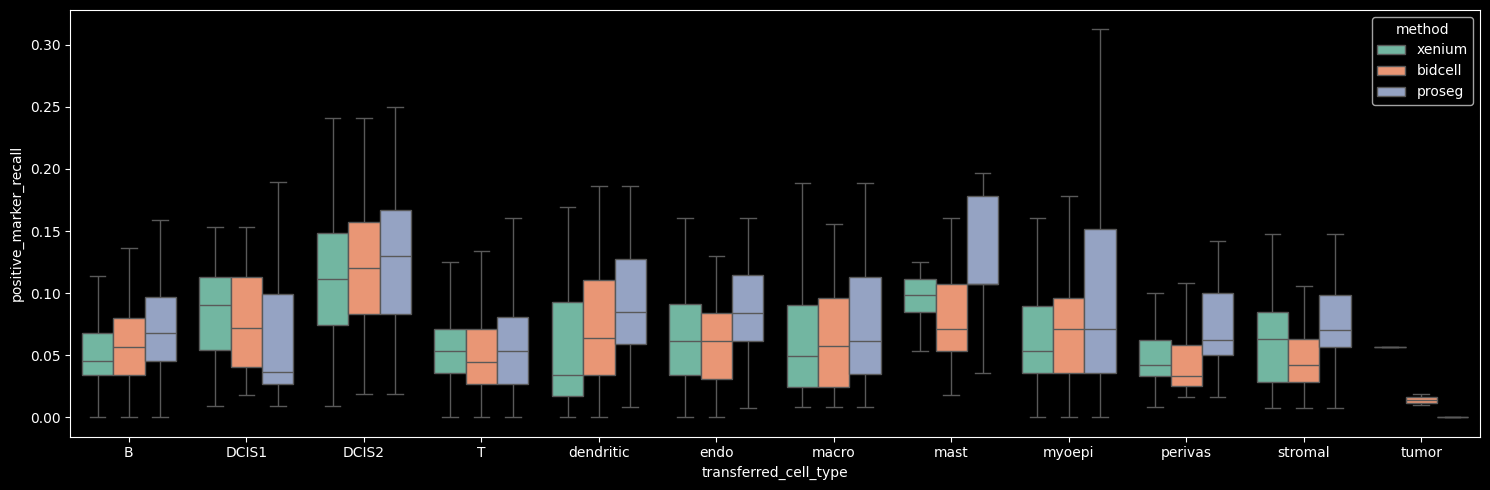

In [55]:
boxplot_per_celltype(st_dict, "positive_marker_recall")

These metrics are most informative when considered jointly. For example, we plot the mean
`negative_marker_avoidance` (a supervised measure of contamination) against the mean
`border_admixture_score`, an unsupervised contamination metric. In this combined view,
we can see that the two transcript-informed methods, BIDCell and Proseg,
show marginally less contamination than the transcript-agnostic segmentation method from Xenium.

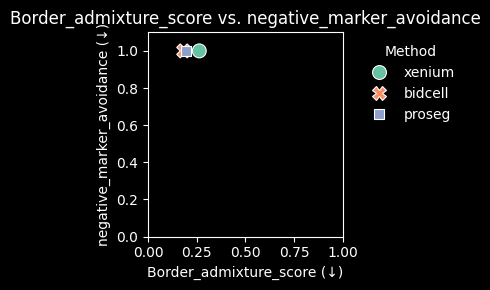

In [56]:
rows = []
for _method, st in st_dict.items():
    corr_ncv_vs_center = st.sdata.tables["table"].obs["border_admixture_score"].median()
    negative_F1 = st.sdata.tables["table"].obs["negative_marker_avoidance"].median()

    rows.append(
        {
            "Method": _method,
            "Border_admixture_score": corr_ncv_vs_center,
            "negative_marker_avoidance": negative_F1,
        }
    )

results_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(4, 3))

sns.scatterplot(
    data=results_df,
    x="Border_admixture_score",
    y="negative_marker_avoidance",
    hue="Method",
    style="Method",
    s=100,
    palette="Set2",
    ax=ax,
)

ax.set_xlabel("Border_admixture_score (↓)")
ax.set_ylabel("negative_marker_avoidance (↓)")
ax.set_title("Border_admixture_score vs. negative_marker_avoidance")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)

legend = ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
plt.show()

*Neighborhood contamination*

Marker purity summarizes how well a cell matches its own markers and avoids neighborhood-relevant negatives.
In many cases, we also want to quantify
(i) **how many contaminating transcripts** are present per cell and
(ii) **which neighboring cell types** contribute to this signal.
We therefore compute neighborhood contamination.

In [57]:
for method, st in st_dict.items():
    per_cell_df, _, cont_bin, _ = st.sp.neighbor_contamination(
        cell_type_key="transferred_cell_type", markers=markers[method]
    )

Among the evaluated methods, Proseg yields the smallest number of cells showing detectable contamination.
Across methods, the highest number of cells affected by contamination are found among T and B cells.

In [58]:
methods_df = []

for method, st in st_dict.items():
    obs = st.sdata.tables["table"].obs
    counts = obs.loc[obs["contamination_counts"] > 0, "transferred_cell_type"].value_counts().rename(method)
    methods_df.append(counts)

merged = pd.concat(methods_df, axis=1)
merged

,xenium,bidcell,proseg
transferred_cell_type,,,
T,27,37,12
DCIS1,10,7,4
DCIS2,8,4,5
macro,8,13,8
B,7,5,1
dendritic,6,5,4
stromal,5,6,4
endo,1,6,2
mast,1,2,6


Proseg contains the lowest number of T cells and B cells, and hence the overall
contamination will be lower than for the other methods.

In [59]:
methods_df = []

for method, st in st_dict.items():
    obs = st.sdata.tables["table"].obs

    counts = obs["transferred_cell_type"].value_counts().rename(method)

    methods_df.append(counts)

pd.concat(methods_df, axis=1).fillna(0)

,xenium,bidcell,proseg
transferred_cell_type,,,
T,192,198,165
DCIS2,160,151,149
B,94,84,67
stromal,59,66,70
macro,51,42,46
endo,38,40,37
myoepi,33,34,25
dendritic,31,30,21
DCIS1,19,23,17


It therefore makes sense to compute the percentage of cells per celltype affected by contamination.

In [60]:
rows = []

for method, st in st_dict.items():
    obs = st.sdata.tables["table"].obs

    total = obs["transferred_cell_type"].value_counts()
    contaminated = obs.loc[obs["contamination_counts"] > 0, "transferred_cell_type"].value_counts()

    frac = (contaminated / total).rename(method)

    rows.append(frac)
merged_frac = pd.concat(rows, axis=1).fillna(0)
merged_frac

,xenium,bidcell,proseg
transferred_cell_type,,,
B,0.074468,0.059524,0.014925
DCIS1,0.526316,0.304348,0.235294
DCIS2,0.050000,0.026490,0.033557
T,0.140625,0.186869,0.072727
dendritic,0.193548,0.166667,0.190476
endo,0.026316,0.150000,0.054054
macro,0.156863,0.309524,0.173913
mast,0.083333,0.181818,0.461538
myoepi,0.030303,0.058824,0.080000


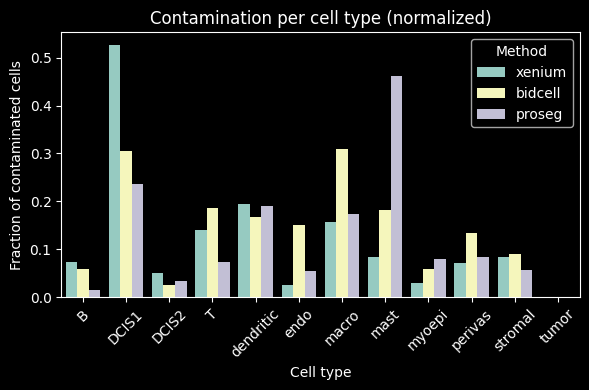

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

df_long = merged_frac.reset_index().melt(
    id_vars="transferred_cell_type", var_name="Method", value_name="fraction_contaminated"
)

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=df_long,
    x="transferred_cell_type",
    y="fraction_contaminated",
    hue="Method",
    ax=ax,
)

ax.set_ylabel("Fraction of contaminated cells")
ax.set_xlabel("Cell type")
ax.set_title("Contamination per cell type (normalized)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The spatial plot below shows the number of contaminating transcripts in each cell.

In [62]:
def plot_feature_labels(sdata, method, feature, axes, i):
    labels = sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
    cols = [col_celltype[lab] for lab in labels]

    sdata.tables["table"].obs["region"] = "cell_boundaries"
    sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color="transferred_celltype_plot",
        palette=cols,
        groups=labels,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[0, i], title=f"{method}:Cell boundaries colored by cell type", coordinate_systems="global")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color=feature,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[1, i], title=f"{method}: {feature}", coordinate_systems="global")

WARNING  render_shapes: Found 160 NaN values in color data. These observations will be colored with the 'na_color'.


WARNING  render_shapes: Found 172 NaN values in color data. These observations will be colored with the 'na_color'.


WARNING  render_shapes: Found 237 NaN values in color data. These observations will be colored with the 'na_color'.


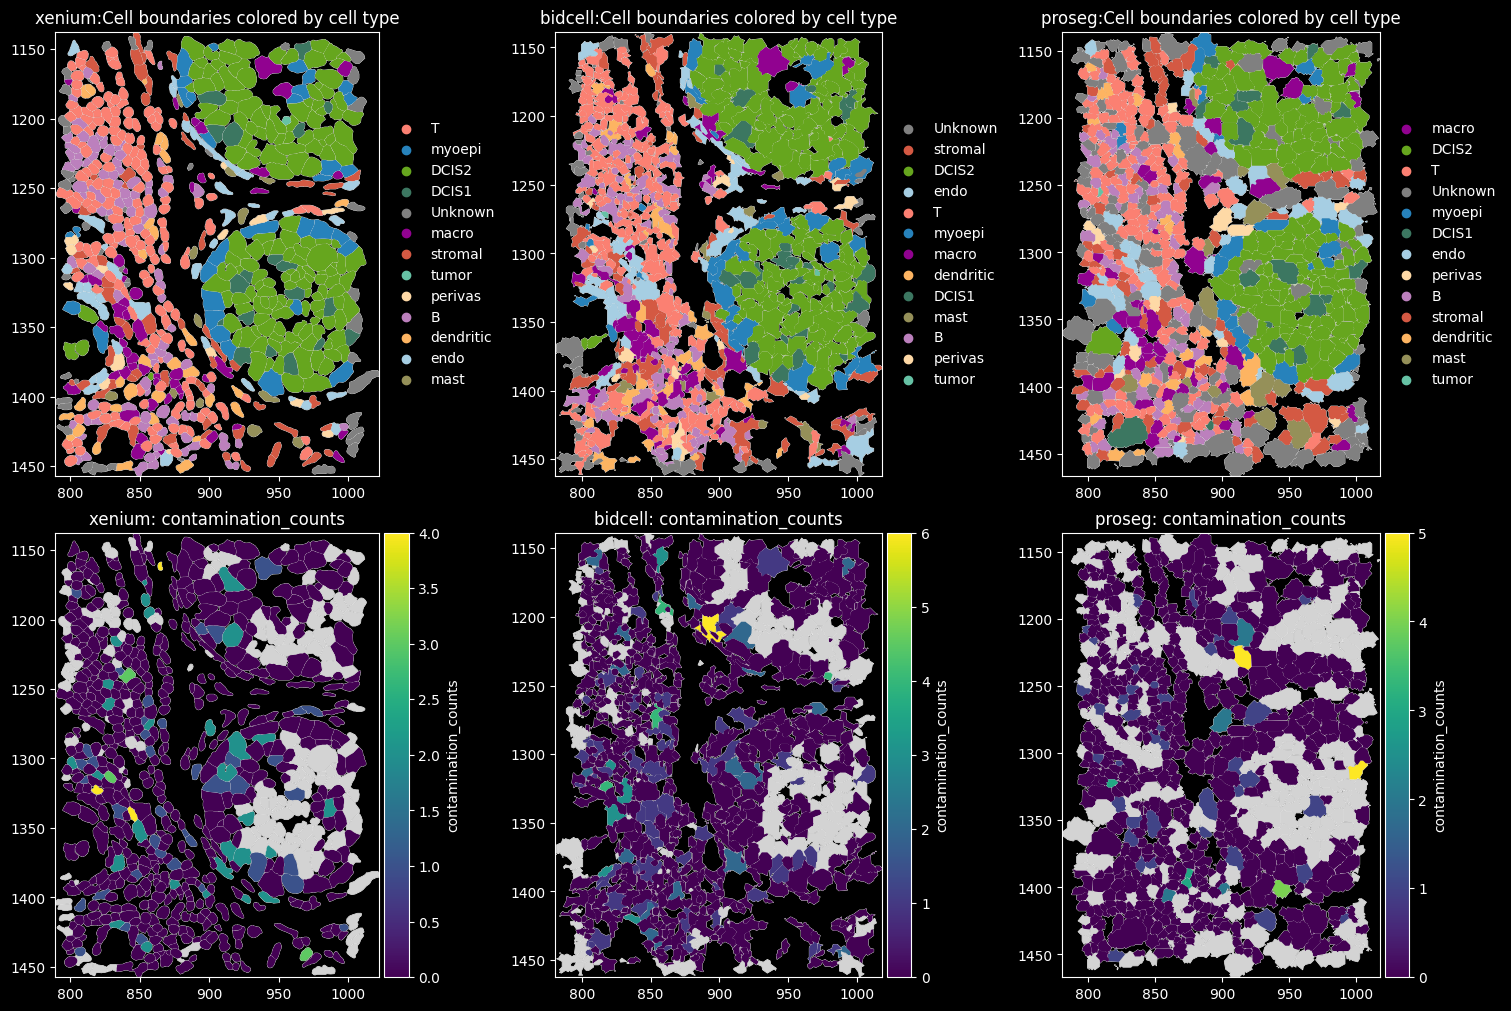

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = np.atleast_2d(axes)
for i, (method, st) in enumerate(st_dict.items()):
    plot_feature_labels(st.sdata, method, "contamination_counts", axes, i)

The heatmap below summarizes contamination strength for each source–target cell-type pair.
Each entry represents the mean contamination strength across all evaluable target cells
of the given target cell type, where the source-specific contamination strength is computed
as the fraction of transcripts in the target cell that correspond to contamination-relevant
markers of the source cell type.

The bubble plot illustrates the contamination strength (bubble color) and the
number of evaluable target cells (bubble size).

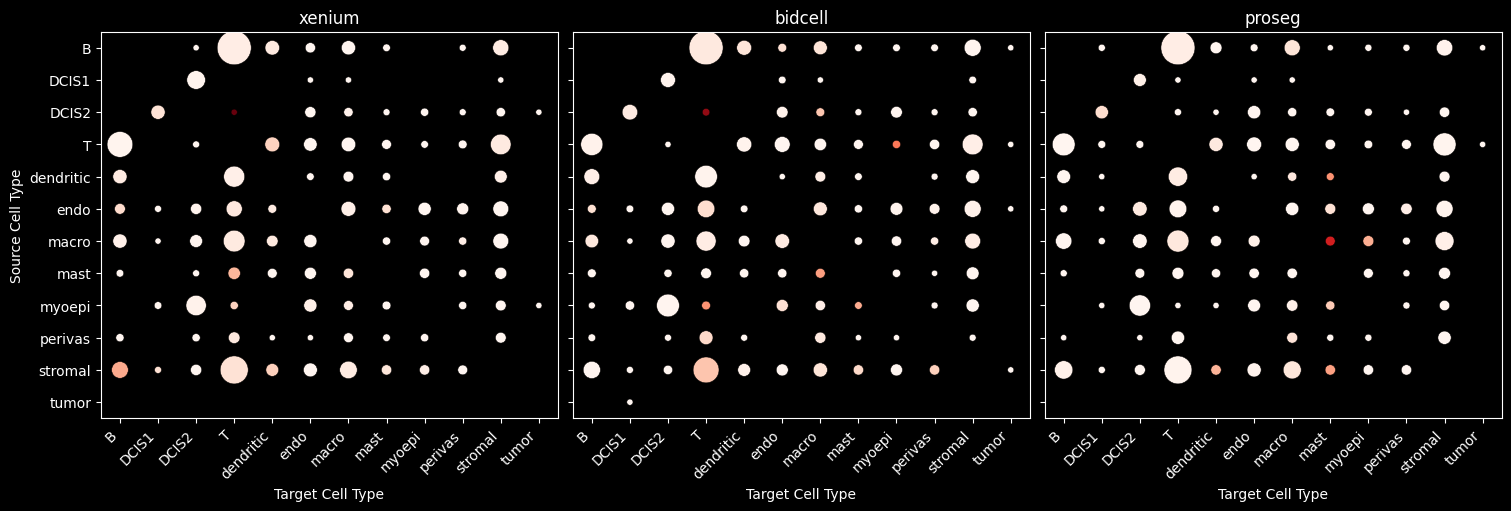

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize

vmax = max(st.sdata.tables["table"].uns["contamination_strength_matrix"].max().max() for st in st_dict.values())
norm = Normalize(vmin=0, vmax=vmax)

cell_type_order = list(next(iter(st_dict.values())).sdata.tables["table"].uns["contamination_strength_matrix"].columns)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for i, (method, st) in enumerate(st_dict.items()):
    cont_strength = st.sdata.tables["table"].uns["contamination_strength_matrix"]
    cont_n = st.sdata.tables["table"].uns["contamination_evaluable_cells_matrix"]

    # Force same source/target order and include missing rows/columns.
    cont_strength = cont_strength.reindex(
        index=cell_type_order,
        columns=cell_type_order,
    )
    cont_n = cont_n.reindex(
        index=cell_type_order,
        columns=cell_type_order,
    )

    plot_df = (
        cont_strength.stack(dropna=False)
        .rename("contamination_strength")
        .reset_index()
        .rename(columns={"level_0": "source", "level_1": "target"})
    )

    plot_df["n_evaluable"] = cont_n.stack(dropna=False).values
    plot_df = plot_df.dropna(subset=["n_evaluable"])

    plot_df["target"] = pd.Categorical(
        plot_df["target"],
        categories=cell_type_order,
        ordered=True,
    )
    plot_df["source"] = pd.Categorical(
        plot_df["source"],
        categories=cell_type_order,
        ordered=True,
    )

    sns.scatterplot(
        data=plot_df,
        x="target",
        y="source",
        size="n_evaluable",
        hue="contamination_strength",
        sizes=(20, 600),
        palette="Reds",
        hue_norm=norm,
        edgecolor="black",
        legend=False,
        ax=axes[i],
    )

    axes[i].set_title(method, fontsize=12)
    axes[i].set_xlabel("Target Cell Type")
    axes[i].set_xlim(-0.5, len(cell_type_order) - 0.5)
    axes[i].set_ylim(len(cell_type_order) - 0.5, -0.5)

    axes[i].set_xticks(range(len(cell_type_order)))
    axes[i].set_xticklabels(cell_type_order, rotation=45, ha="right")

    axes[i].set_yticks(range(len(cell_type_order)))
    if i == 0:
        axes[i].set_ylabel("Source Cell Type")
        axes[i].set_yticklabels(cell_type_order)
    else:
        axes[i].set_ylabel("")
        axes[i].set_yticklabels([])

plt.show()

*Mutually exclusive co-expression rate (MECR)*

The mutually exclusive co-expression rate (MECR) is a measure for whether
combinations of positive and negative markers (computed with a more stringent setting
to increase mutual exclusivity, `vote_frac_pos=0.3`) co-occur less often than
expected under independence (using Fisher's exact test). By conditioning on the
marginal detection frequencies of each gene, Fisher’s exact test does not favor
methods with low overall transcript counts.

In [65]:
markers = {}

for method, st in st_dict.items():
    markers[method] = st.markers_from_reference(
        adata_ref,
        ref_cell_type="celltype_major",
        min_pos_frac=0.3,
        ref_raw_counts_layer="raw",
        n_jobs=16,
    )

    mecr = st.sp.mutually_exclusive_coexpression_rate(
        markers=markers[method],
    )

Across all methods, positive and negative markers co-occur less frequently than expected
under independence, indicating a consistent depletion of co-expression.
Although the differences are minor, Proseg shows the strongest depletion of co-expression
of positive and negative markers.

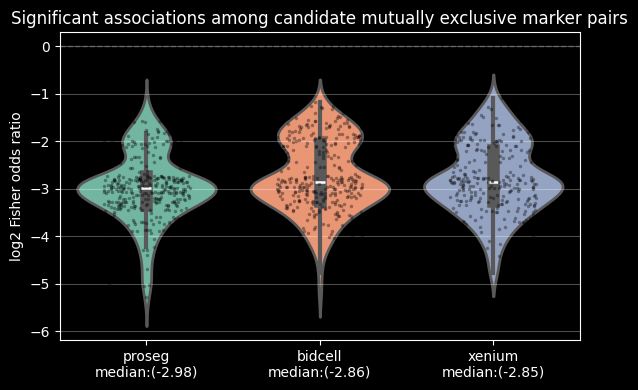

In [66]:
rows = []

for method, st in st_dict.items():
    tbl = st.sdata.tables["table"]
    mecr_df = tbl.uns["mutually_exclusive_coexpression_rate"]

    # Filter significant, finite odds ratios and p-values
    df_sig = mecr_df[
        mecr_df["odds_ratio"].notna()
        & np.isfinite(mecr_df["odds_ratio"])
        & mecr_df["pvalue"].notna()
        & np.isfinite(mecr_df["pvalue"])
        & (mecr_df["pvalue"] < 0.05)
    ]

    # Build rows
    rows.extend({"method": str(method), "Fisher_OR": np.log2(row["odds_ratio"])} for _, row in df_sig.iterrows())

df = pd.DataFrame(rows)

median_order = df.groupby("method")["Fisher_OR"].median().sort_values().index.tolist()
medians = df.groupby("method")["Fisher_OR"].median().reindex(median_order)

xtick_labels = [f"{m}\nmedian:({medians[m]:.2f})" for m in median_order]

plt.figure(figsize=(6, 4))

ax = sns.violinplot(
    data=df,
    x="method",
    y="Fisher_OR",
    order=median_order,
    palette="Set2",
    linewidth=2,
)

sns.stripplot(
    data=df,
    x="method",
    y="Fisher_OR",
    order=median_order,
    color="black",
    size=2.5,
    alpha=0.35,
    jitter=0.25,
    ax=ax,
)

# Reference line: OR = 1
ax.axhline(0, ls="--", lw=1, color="gray", alpha=0.6)

ax.set_xticklabels(xtick_labels)

ax.set_ylabel("log2 Fisher odds ratio")
ax.set_xlabel("")
ax.set_title("Significant associations among candidate mutually exclusive marker pairs")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3D Volume Module

The volume (`vl`) accessor provides metrics to assess how well a segmentation method
resolves cell overlaps in 3D. Spatial transcriptomics tissue sections have a finite
thickness (~4–10 µm), so cells can overlap along the z-dimension and 2D segmentation
methods may introduce mixing by assigning transcripts from overlapping cells to the same mask.
In this module, we introduce metrics to quantify sensitivity to 3D overlap and evaluate how
well quasi-3D methods (e.g. Proseg) disentangle transcripts from overlapping cells.

For a detailed description of this module, please refer to this [tutorial](volume.ipynb).

*Top-bottom z consistency*

To detect potential z-overlap mixing within segmented cells, we split each cell’s
transcripts into bottom/top z-quantiles (q=0.30), compute log-normalized gene profiles
for both parts, and report their cosine similarity (NaN if either part has <10 transcripts or <5 genes).

In [67]:
for _method, st in st_dict.items():
    _cos_sim = st.vl.similarity_top_bottom()

Proseg 2 shows the highest expression similarity between top and bottom plane both
overall and on a cell type level. This is also true for cell types,
for which proseg has a lower per-cell transcript counts such as myoepithelial and DCIS2 cells.

The other three methods have peaks at zero, which means that top and bottom parts
have completely different gene compositions (genes present in one are essentially absent in the other).

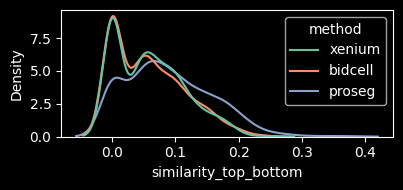

In [68]:
feature = ["similarity_top_bottom"]
density_plot_feature(st_dict, feature)

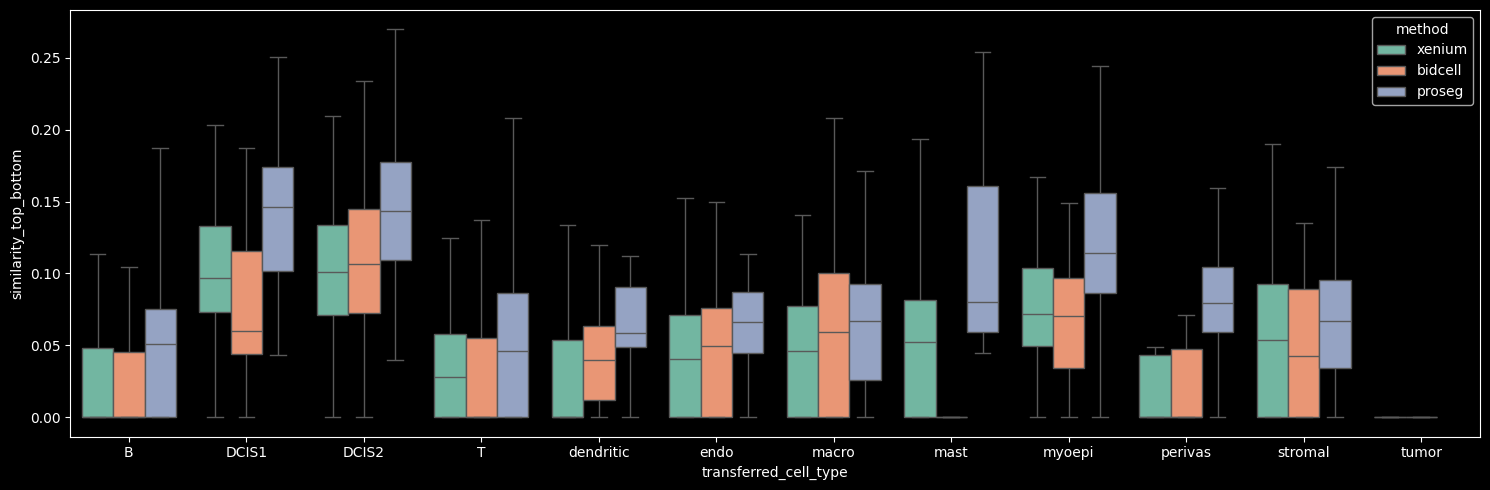

In [69]:
boxplot_per_celltype(st_dict, "similarity_top_bottom")

In [volume.ipynb](./volume.ipynb), we explore the distribution of transcripts along the z-dimension
in more depth and put it into context with
[ovrlpy](https://www.biorxiv.org/content/10.1101/2025.01.13.632601v2.full),
a package for detecting 3D overlap in spatial transcriptomics.

### Point statistic metrics

The point statistics (`ps`) module is designed to compare the
distribution of a set of transcripts in the cell relative to its cell centroid or cell border.
The idea is to compute the distances of the transcripts to a reference point in the cell,
either the cell centroid or the cell boundaries and aggregate this measure per transcript id.

_distance to membrane metric_

In this metric we compute the distance to the segmented cell membrane of each transcript coordinate
and aggregate this metric per transcript id as mean.

In [70]:
plt.style.use("dark_background")


def plot_metric(sdata, boundary_key, method, metric, genes, ax):
    sdata_plot = sd.deepcopy(sdata)
    sdata_plot["table"] = sdata_plot["table"][(sdata_plot["table"].obs[metric].notna())]

    sdata_plot.tables["table"].obs["region"] = boundary_key
    sdata_plot.set_table_annotates_spatialelement("table", region=boundary_key)

    sdata_plot.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color=metric,
        cmap="viridis",
        fill_alpha=0.5,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_points(
        "transcripts",
        color="feature_name",
        groups=genes,
        palette=["red"] * len(genes),
    ).pl.show(ax=ax, title="Cell/nuclei seg. for " + method + " " + metric, colorbar=True)

    return fig, axes

First, we compute both the average distance to the cell membrane across all previously
defined negative and positive markers for the cell type "DCIS1".

In [71]:
border_distance_negative = {}
border_distance_positive = {}

for method, st in st_dict.items():
    border_distance_negative[method] = st.ps.distance_to_membrane(
        markers[method]["DCIS1"]["negative"],
        cell_type_key="transferred_celltype_plot",
        cell_type_query=["DCIS1"],
        restrict_to_within_boundary=True,
        inplace=False,
    )
    border_distance_positive[method] = st.ps.distance_to_membrane(
        markers[method]["DCIS1"]["positive"],
        cell_type_key="transferred_celltype_plot",
        restrict_to_within_boundary=True,
        cell_type_query=["DCIS1"],
        inplace=False,
    )

In [72]:
keys = []
values = []

for key, df in border_distance_negative.items():
    for val in df["distance_to_cell_membrane_norm_166_genes"]:
        keys.append(key)
        values.append(val)

result_negative = pd.DataFrame({"method": keys, "distance": values, "marker": "negative"})

keys = []
values = []

for key, df in border_distance_positive.items():
    for val in df["distance_to_cell_membrane_norm_78_genes"]:
        keys.append(key)
        values.append(val)

result_positive = pd.DataFrame({"method": keys, "distance": values, "marker": "positive"})

In [73]:
result = pd.concat([result_negative, result_positive])
result = result.dropna()

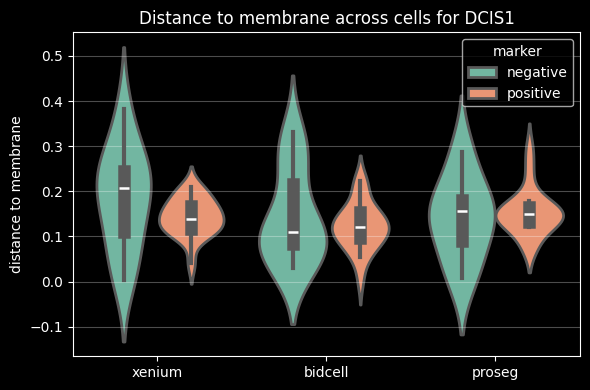

In [74]:
plt.figure(figsize=(6, 4))

ax = sns.violinplot(
    data=result,
    x="method",
    y="distance",
    hue="marker",
    palette="Set2",
    linewidth=2,
)

ax.set_ylabel("distance to membrane")
ax.set_xlabel("")
ax.set_title("Distance to membrane across cells for DCIS1")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

We can plot now the distance to membrane for the positive and negative markers
across the different segmentation algorithms and for the cell type "DCIS1".

We can also run the method inplace and plot the results in space

In [75]:
for _method, st in st_dict.items():
    st.ps.distance_to_membrane(
        markers[method]["DCIS1"]["negative"],
        cell_type_key="transferred_celltype_plot",
        cell_type_query=["DCIS1"],
        restrict_to_within_boundary=True,
        inplace=True,
    )

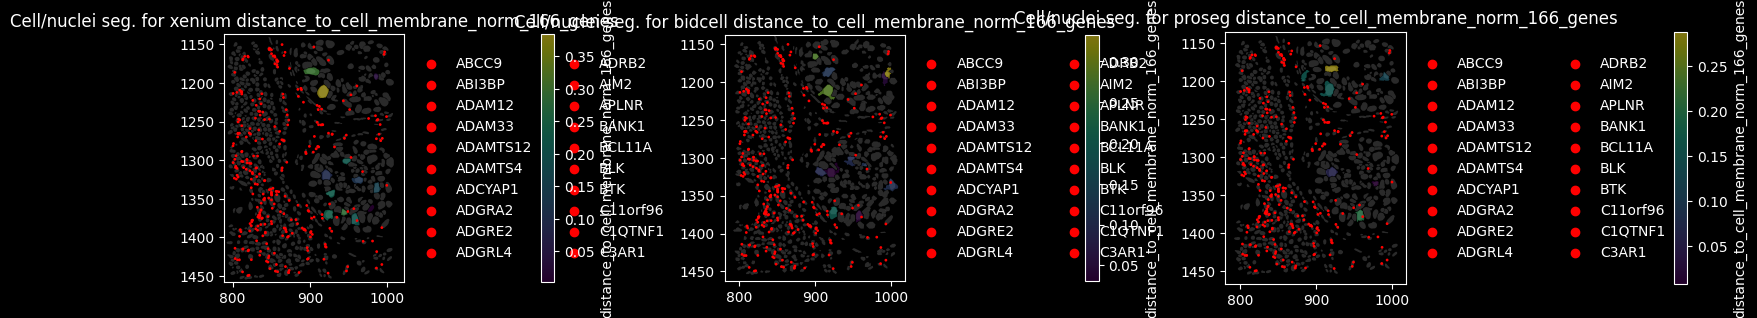

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10), constrained_layout=True)

for i, (method, st) in enumerate(st_dict.items()):
    plot_metric(
        st.sdata,
        "cell_boundaries",
        method,
        "distance_to_cell_membrane_norm_166_genes",
        markers[method]["DCIS1"]["negative"][:20],
        axes[i],
    )

We can identify cells in which the distribution of negative markers is clearly
more skewed than for thers and that these values differ again greatly between the segmentation algorithms.

### Metrics orthogonolisation

In order to look at the co-linearity of the computed metrics,
we will compute the correlation matrix (scaled covariance matrix) of all the metrics.
Since the directionality (positively or negatively correlated) does not matter,
we take the absolute value of the correlation coefficient as our orthogonality metric.
Like this, we can visualise which metrics correlate

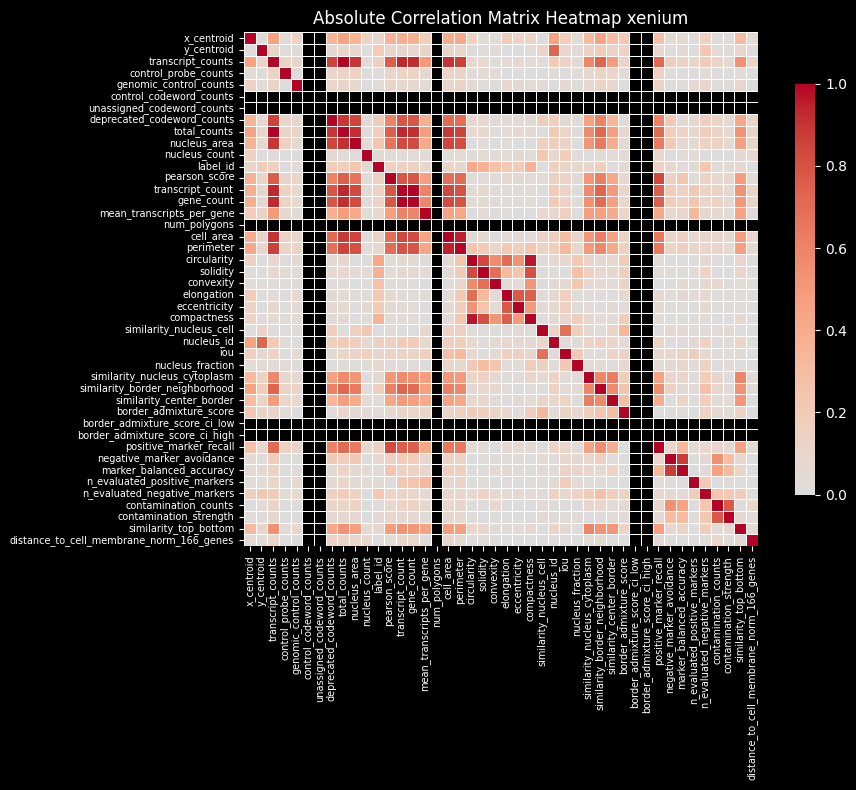

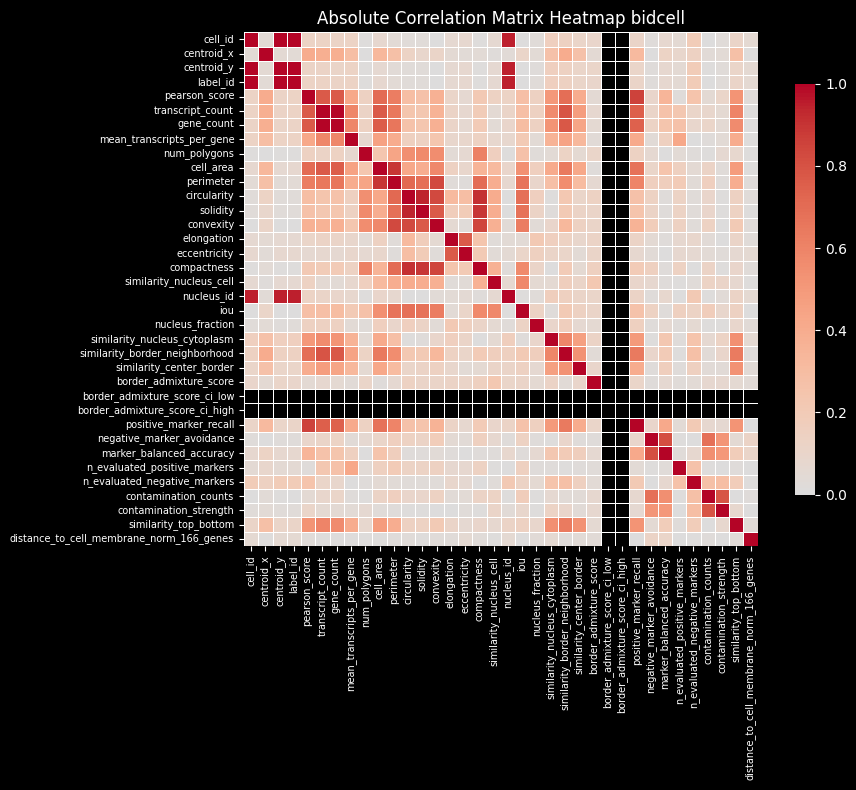

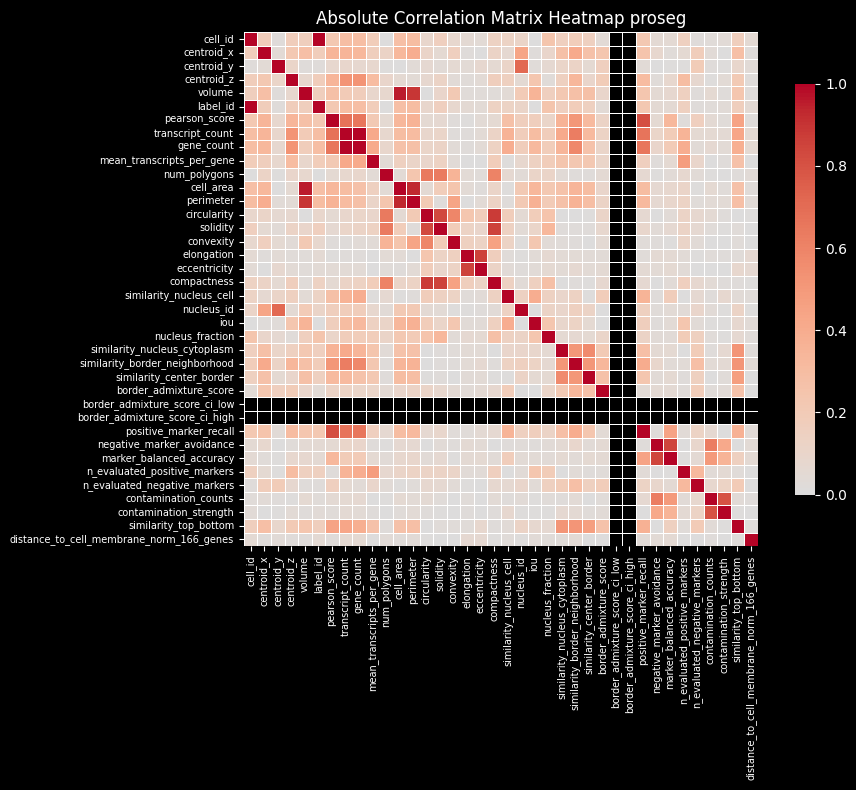

In [77]:
# code adapted from claude.ai
for method, st in st_dict.items():
    df = st.sdata.tables["table"].obs
    df_numeric = df.select_dtypes(include="number")
    df = pd.DataFrame(df_numeric, columns=df_numeric.columns, index=df_numeric.index)
    # correlation does not work with NA values. Fill NA with columnwise mean
    df = df.apply(lambda x: x.fillna(x.mean()), axis=0)
    correlation_matrix = df.corr()

    # take absolute value instead - sign is not important, only co-linearity
    correlation_matrix = correlation_matrix.abs()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlation_matrix,
        annot=False,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        vmin=0,
        vmax=1,
        xticklabels=correlation_matrix.columns,
        yticklabels=correlation_matrix.columns,
    )
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.title(f"Absolute Correlation Matrix Heatmap {method}")
    plt.tight_layout()
    plt.show()

There are quite some metrics which correlate with the segmented cell area,
such as total counts of all transcripts and metrics related to this.
We note as well that the correlation of metrics differs between algorithms.

## Session Info

In [78]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.8.0
0.4.0
